# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip uninstall -y numpy pandas matplotlib seaborn
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2
# matching the versions as instructed

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [5]:
# Try loading one file

df = pd.read_parquet('/content/2023-05.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2889185 entries, 0 to 2913954
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import pandas as pd

# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# List of files for each month in 2023
file_list = [f'/content/2023-{str(i).zfill(2)}.parquet' for i in range(1, 13)]

# initialise an empty dataframe
final_df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_path in file_list:
    try:
        print(f'Processing {file_path}...')
        # Reading the current file
        month_data = pd.read_parquet(file_path)

        # Extract date and hour for grouping
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # Sample 5% from each hour of every date (this handles the nested loop logic efficiently)
        sampled_month = month_data.groupby(['pickup_date', 'pickup_hour']).apply(
            lambda x: x.sample(frac=0.05, random_state=42)
        ).reset_index(drop=True)

        # Concatenate the sampled data of all the dates to a single dataframe
        final_df = pd.concat([final_df, sampled_month], ignore_index=True)

    except Exception as e:
        print(f'Error reading file {file_path}: {e}')

# Update the main df variable
df = final_df
print(f'Sampling complete. Total rows: {len(df)}')
display(df.head())

Processing /content/2023-01.parquet...
Processing /content/2023-02.parquet...
Processing /content/2023-03.parquet...
Processing /content/2023-04.parquet...
Processing /content/2023-05.parquet...
Processing /content/2023-06.parquet...
Processing /content/2023-07.parquet...
Processing /content/2023-08.parquet...
Processing /content/2023-09.parquet...
Processing /content/2023-10.parquet...
Processing /content/2023-11.parquet...
Processing /content/2023-12.parquet...
Sampling complete. Total rows: 1896400


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [9]:
# Store the df in csv/parquet
df.to_parquet('final.parquet')
print(f"Done creating file.")

Done creating file.


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [10]:
# Load the new data file
df = pd.read_parquet('final.parquet')
print(f"Got: {len(df):,} rows")

Got: 1,896,400 rows


In [11]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [13]:
# Fix the index and drop any columns that are not needed

df.reset_index(drop=True, inplace=True)
df = df.drop(['pickup_date', 'pickup_hour'], axis=1)

print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

# Remaining columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee']
# Shape: (1915511, 20)

Remaining columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee']
Shape: (1896400, 20)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [14]:
# Combine the two airport fee columns
# looks like same column is there twice with minor name difference, so using fillna to take whichever has value
df['airport_fee_combined'] = df['Airport_fee'].fillna(df['airport_fee'])

# Drop the old redundant columns as we have airport_fee_combined now
df = df.drop(columns=['Airport_fee', 'airport_fee'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [15]:
# check where values of fare amount are negative
neg_fare_df = df[df['fare_amount'] < 0]
print(f"Rows with negative fare_amount: {len(neg_fare_df)}")
neg_fare_df.head(10)

Rows with negative fare_amount: 0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined


Did you notice something different in the `RatecodeID` column for above records?

In [16]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] < 0]['RatecodeID'].value_counts()


,count
RatecodeID,


In [17]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=['number'])
negative_columns = numeric_cols.loc[:, (numeric_cols < 0).any()].columns
print("Columns with negative values:", list(negative_columns))

Columns with negative values: ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined']


In [18]:
# fix these negative values
for col in negative_columns:
    df.loc[df[col] < 0, col] = 0

print("Fixed. Recheck remaining negatives.")
for col in negative_columns:
    print(f"  {col}: {(df[col] < 0).sum()} values remaining")

Fixed. Recheck remaining negatives.
  extra: 0 values remaining
  mta_tax: 0 values remaining
  improvement_surcharge: 0 values remaining
  total_amount: 0 values remaining
  congestion_surcharge: 0 values remaining
  airport_fee_combined: 0 values remaining


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [19]:
# Find the proportion of missing values in each column
df.isnull().mean() * 100

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,3.420903
trip_distance,0.000000
RatecodeID,3.420903
store_and_fwd_flag,3.420903
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [20]:
# Display the rows with null values
print("Rows with any null values:")
display(df[df.isnull().any(axis=1)].head())

# Impute NaN values in 'passenger_count'
df.fillna({'passenger_count': df['passenger_count'].mode()[0]}, inplace=True)

# Solution for: Did you find zeroes in passenger_count? Handle these
zero_pax = (df['passenger_count'] == 0).sum()
print(f"\nZero passenger_count rows before fix: {zero_pax}")

# zeros replaced with mode (since you cant have 1.5 people in a cab)
if zero_pax > 0:
    passenger_mode = df['passenger_count'].mode()[0]
    df.loc[df['passenger_count'] == 0, 'passenger_count'] = passenger_mode
    print(f"Replaced {zero_pax} zero-passenger rows with mode ({int(passenger_mode)})")

print(f"Zero passenger_count rows after fix: {(df['passenger_count'] == 0).sum()}")

Rows with any null values:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
5,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN
16,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN
43,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,NaN
44,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,NaN
47,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,NaN



Zero passenger_count rows before fix: 29681
Replaced 29681 zero-passenger rows with mode (1)
Zero passenger_count rows after fix: 0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [21]:
# Fix missing values in 'RatecodeID'
print(f"Null RatecodeID records: {df['RatecodeID'].isnull().sum()}")
print("RatecodeID records before fix:")
print(df['RatecodeID'].value_counts())

df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])
print(f"\nNull RatecodeID records after fix: {df['RatecodeID'].isnull().sum()}")

Null RatecodeID records: 64874
RatecodeID records before fix:
RatecodeID
1.0     1729259
2.0       71670
99.0      10472
5.0       10275
3.0        6124
4.0        3723
6.0           3
Name: count, dtype: int64

Null RatecodeID records after fix: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [22]:
# handle null values in congestion_surcharge

print(f"Null congestion_surcharge: {df['congestion_surcharge'].isnull().sum()}")

# Impute with median
df['congestion_surcharge'].fillna(df['congestion_surcharge'].median(), inplace=True)

print(f"Null after fix: {df['congestion_surcharge'].isnull().sum()}")
print("Value distribution:", df['congestion_surcharge'].value_counts().head())


Null congestion_surcharge: 64874
Null after fix: 0
Value distribution: congestion_surcharge
2.5    1755446
0.0     140953
0.5          1
Name: count, dtype: int64


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [23]:
# Handle any remaining missing values

# first lets check remaining missing values
print("Remaining missing value proportions (%):")
remaining = df.isnull().mean() * 100
print(remaining[remaining > 0])

# store_and_fwd_flag: fill with mode
df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)

# airport_fee_combined: fill with 0 (no airport fee)
df['airport_fee_combined'].fillna(0, inplace=True)

print(f"\nTotal null values remaining: {df.isnull().sum().sum()}")


Remaining missing value proportions (%):
store_and_fwd_flag      3.420903
airport_fee_combined    3.420903
dtype: float64

Total null values remaining: 0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

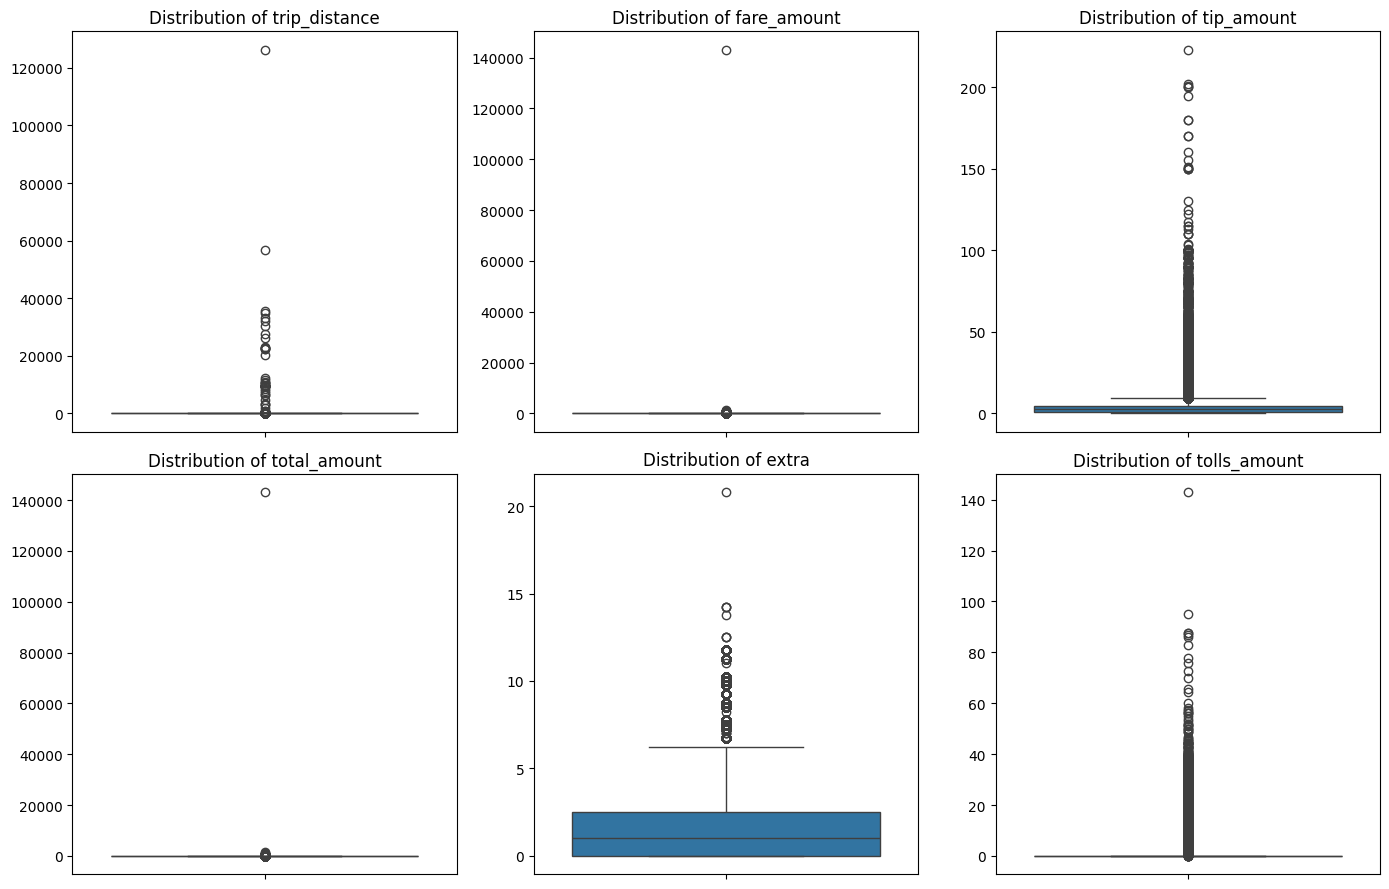

In [24]:
# Describe the data and check if there are any potential outliers present
df.describe()

# Check for potential out of place values in various columns
columns_of_interest = [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'extra',
    'tolls_amount'
]
plt.figure(figsize=(14, 9))

for idx, column in enumerate(columns_of_interest, start=1):
    plt.subplot(2, 3, idx)
    sns.boxplot(data=df, y=column)
    plt.title(f'Distribution of {column}')
    plt.ylabel('')

plt.tight_layout()
plt.show()


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [25]:
# remove passenger_count > 6
before = len(df)
df = df[df['passenger_count'] <= 6]
print(f"Removed {before - len(df)} rows with passenger_count > 6. Remaining: {len(df):,}")

Removed 21 rows with passenger_count > 6. Remaining: 1,896,379


In [26]:
# Continue with outlier handling
before = len(df)

# 1. zero distance with suspiciously high fare — clearly wrong
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# 2. both zero but pickup != dropoff — impossible trip, likely a logging error
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) &
          (df['PULocationID'] != df['DOLocationID']))]

# 3. anything over 250 miles is well outside NYC — not a real taxi trip
df = df[df['trip_distance'] <= 250]

# 4. payment_type = 0 doesn't exist in the data dictionary
df = df[df['payment_type'] != 0]

# 5. negative trip durations (if duration feature already exists)
if 'trip_duration_min' in df.columns:
    df = df[df['trip_duration_min'] >= 0]

# 6. added filters for clearly invalid fare values

df = df[df['fare_amount'] > 0]       # zero fare (non-dispute) doesn't make sense
df = df[df['fare_amount'] < 1000]    # anything over $1000 is almost certainly an error
df = df[df['total_amount'] < 1000]   # same logic for total amount

# 7. reset index after all the filtering — keeps things tidy
df = df.reset_index(drop=True)       # #FIXED — was missing after row drops


print(f"Rows removed: {before - len(df)}")
print(f"Remaining rows: {len(df):,}")



Rows removed: 65565
Remaining rows: 1,830,814


In [27]:
# Do any columns need standardising?

# Added columns as required later

# Ensuring datetime columns are proper dtype
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Add trip duration in minutes
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Add time features for analysis
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6])

# Map payment_type to labels
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided Trip'}
df['payment_label'] = df['payment_type'].map(payment_map)

# Fare per mile (for pricing analysis)
df['fare_per_mile'] = np.where(df['trip_distance'] > 0,
                                df['fare_amount'] / df['trip_distance'], np.nan)

# Average trip speed in mph
df['speed_mph'] = np.where(df['trip_duration_min'] > 0,
                            df['trip_distance'] / (df['trip_duration_min'] / 60), np.nan)

print("Standardisation complete. Final columns:", df.columns.tolist())
print("Shape:", df.shape)


Standardisation complete. Final columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined', 'trip_duration_min', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'is_weekend', 'payment_label', 'fare_per_mile', 'speed_mph']
Shape: (1830814, 28)


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [28]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined',
 'trip_duration_min',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_dayofweek',
 'is_weekend',
 'payment_label',
 'fare_per_mile',
 'speed_mph']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [29]:
# Centralized Functionality

# chart styles - keeping everything consistent throughout the notebook
# defining once here so all plots below can just reference these variables

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

CLR_MAIN   = '#4A7FBF'   # steel blue — standard bars
CLR_PEAK   = '#4CAF7D'   # teal green — peak / max highlights
CLR_LOW    = '#D95F5F'   # soft red — min / low highlights
CLR_ORANGE = '#E07B54'   # warm orange — secondary groups
CLR_PURPLE = '#7B5EA7'   # medium purple — night or special segments
CLR_MUTED  = '#9BB0C4'   # muted blue-grey — neutral bars

CHART_PAL = [CLR_MAIN, CLR_ORANGE, CLR_PEAK, CLR_LOW, CLR_PURPLE, '#F0C040']
print("Theme Ready")

Theme Ready


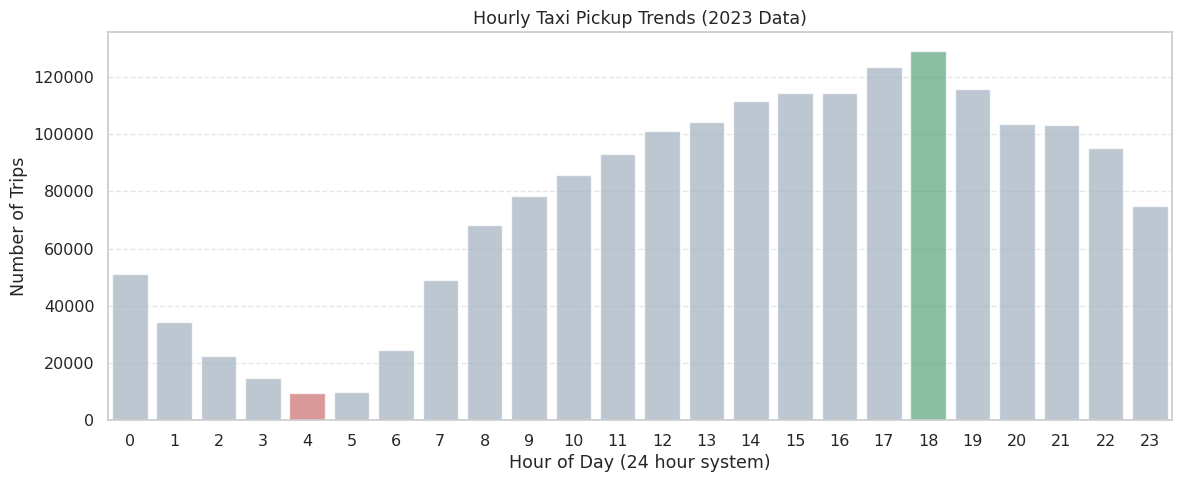

Peak hour: 18:00 with 129,156 trips
Least busy hour: 4:00 with 9,429 trips


In [30]:
# Find and show the hourly trends in taxi pickups

hourly_trips = (df.groupby('pickup_hour').size().reset_index(name='trip_count'))

# find peak and minimum hours
peak_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]
min_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmin()]

colors = []
for i in range(len(hourly_trips)):
    if hourly_trips.loc[i, 'pickup_hour'] == peak_hour['pickup_hour']:
        colors.append(CLR_PEAK)
    elif hourly_trips.loc[i, 'pickup_hour'] == min_hour['pickup_hour']:
        colors.append(CLR_LOW)
    else:
        colors.append(CLR_MUTED)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=hourly_trips,
    x='pickup_hour',
    y='trip_count',
    palette=colors,
    legend=False,
    alpha=0.7
)

# Titles and labels
plt.title('Hourly Taxi Pickup Trends (2023 Data)')
plt.xlabel('Hour of Day (24 hour system)')
plt.ylabel('Number of Trips')
plt.xticks(range(24))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# print both peak and minimum
print(
    f"Peak hour: {int(peak_hour['pickup_hour'])}:00 "
    f"with {peak_hour['trip_count']:,} trips"
)

print(
    f"Least busy hour: {int(min_hour['pickup_hour'])}:00 "
    f"with {min_hour['trip_count']:,} trips"
)

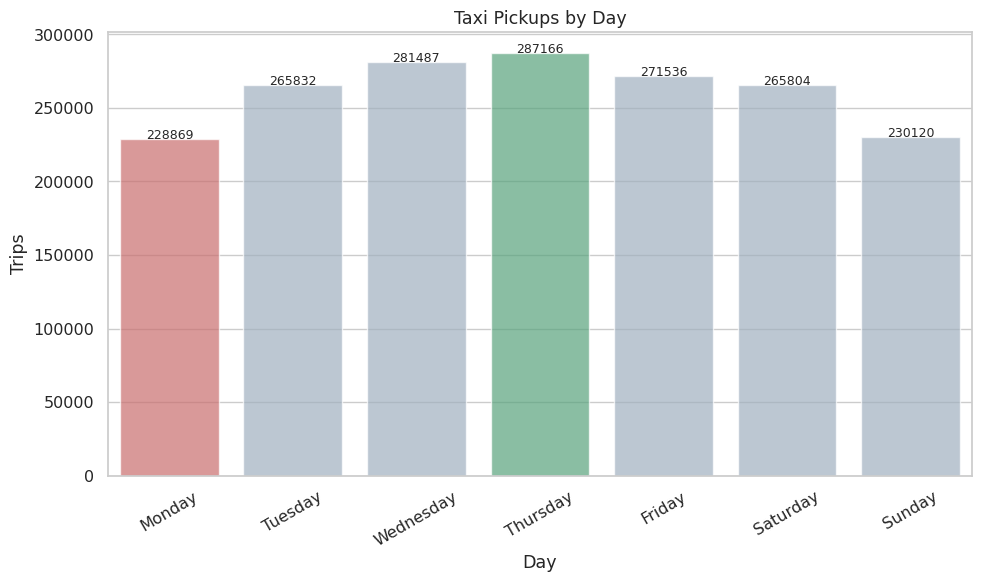

Most busy day: Thursday
Least busy day: Monday


In [31]:
# Find and show the daily trends in taxi pickups (days of the week)

# get day name from datetime
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

# count trips per day
daily_trips = df.groupby('pickup_day')['tpep_pickup_datetime'].count()

# reorder days properly (otherwise looking weird)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_trips = daily_trips.reindex(days)

# convert to dataframe (just easier to plot)
daily_df = daily_trips.reset_index()
daily_df.columns = ['day', 'count']

# find max and min (brownie points)
max_day = daily_df.loc[daily_df['count'].idxmax(), 'day']
min_day = daily_df.loc[daily_df['count'].idxmin(), 'day']

# basic colors (highlight max/min a bit)
colors = []
for d in daily_df['day']:
    if d == max_day:
        colors.append(CLR_PEAK)
    elif d == min_day:
        colors.append(CLR_LOW)
    else:
        colors.append(CLR_MUTED)

plt.figure(figsize=(10, 6))

# bar plot
sns.barplot(
    data=daily_df,
    x='day',
    y='count',
    hue='day', # got some warning about seaborn version hence this fix
    palette=colors,
    alpha=0.7,
    legend=False
)

# labels and stuff
plt.title('Taxi Pickups by Day')
plt.xlabel('Day')
plt.ylabel('Trips')
plt.xticks(rotation=30)

# add numbers on top (not perfectly aligned though)
for i in range(len(daily_df)):
    plt.text(i, daily_df['count'].iloc[i], str(daily_df['count'].iloc[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Most busy day:", max_day)
print("Least busy day:", min_day)


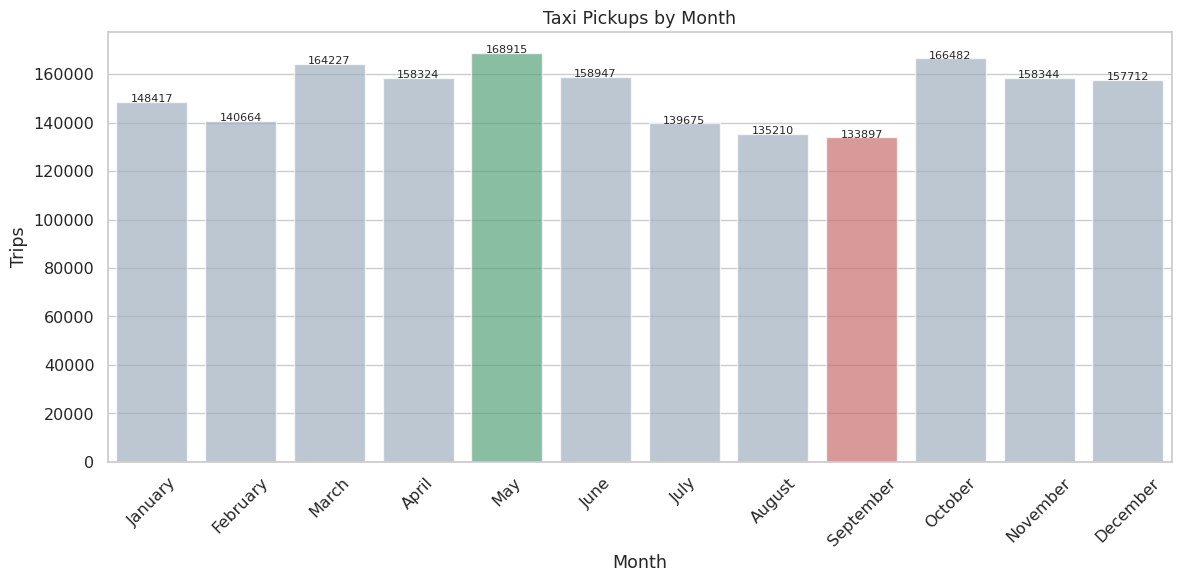

Most busy month: May
Least busy month: September


In [32]:
# Show the monthly trends in pickups

# get month name from datetime
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

# count trips per month
monthly_trips = df.groupby('pickup_month')['tpep_pickup_datetime'].count()

# fix order
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
monthly_trips = monthly_trips.reindex(months)

# make it a dataframe to make it easy dealing
monthly_df = monthly_trips.reset_index()
monthly_df.columns = ['month', 'count']

# find max and min (just for some drama)
max_month = monthly_df.loc[monthly_df['count'].idxmax(), 'month']
min_month = monthly_df.loc[monthly_df['count'].idxmin(), 'month']

# colors (same logic as before, nothing fancy)
colors = []
for m in monthly_df['month']:
    if m == max_month:
        colors.append(CLR_PEAK)
    elif m == min_month:
        colors.append(CLR_LOW)
    else:
        colors.append(CLR_MUTED)

plt.figure(figsize=(12, 6))

# bars
sns.barplot(
    data=monthly_df,
    x='month',
    y='count',
    hue='month',   # just here so seaborn doesn't complain
    palette=colors,
    alpha=0.7,
    legend=False
)

# labels
plt.title('Taxi Pickups by Month')
plt.xlabel('Month')
plt.ylabel('Trips')
plt.xticks(rotation=45)

# numbers on top
for i in range(len(monthly_df)):
    plt.text(i, monthly_df['count'].iloc[i], str(monthly_df['count'].iloc[i]), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Most busy month:", max_month)
print("Least busy month:", min_month)

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [33]:
# Analyse the above parameters

fin_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
analysis_data = pd.DataFrame(columns=fin_cols)
analysis_data.loc['Zero Count'] = [ (df[col] == 0).sum() for col in fin_cols ]
analysis_data.loc['Negative Count'] = [ (df[col] < 0).sum() for col in fin_cols ]
analysis_data.round(2)

,fare_amount,tip_amount,total_amount,trip_distance
Zero Count,0,409675,0,22669
Negative Count,0,0,0,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [34]:
# Create a df with non zero entries for the selected parameters.
df_clean = df[(df['fare_amount'] > 0)
& (df['total_amount'] > 0)
& (df['trip_distance'] > 0)].copy()

print(f"Original rows: {len(df):,}")
print(f"After filtering zeros: {len(df_clean):,} ({len(df_clean)/len(df)*100:.1f}% retained)")


Original rows: 1,830,814
After filtering zeros: 1,808,145 (98.8% retained)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

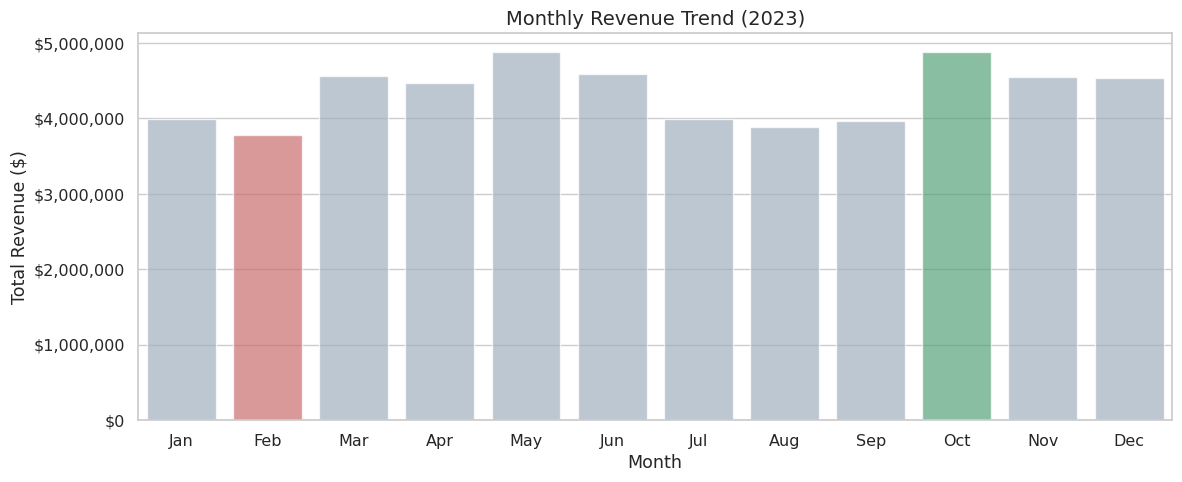

            pickup_month Revenue (USD)
month_name                            
Jan                    1   $3995059.15
Feb                    2   $3776760.48
Mar                    3   $4555917.28
Apr                    4   $4472326.74
May                    5   $4874048.74
Jun                    6   $4584870.64
Jul                    7   $3987014.64
Aug                    8   $3880417.53
Sep                    9   $3961487.63
Oct                   10   $4885719.25
Nov                   11   $4549768.11
Dec                   12   $4529268.88

Highest revenue month: Oct with $4,885,719
Lowest revenue month: Feb with $3,776,760


In [35]:
# Group data by month and analyse monthly revenue

import matplotlib.ticker as mticker

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# make sure month is correct
df_clean['pickup_month'] = df_clean['tpep_pickup_datetime'].dt.month

monthly_rev = df_clean.groupby('pickup_month')['total_amount'].sum().reset_index()

# map names
monthly_rev['month_name'] = monthly_rev['pickup_month'].map(month_names)

# sort
monthly_rev = monthly_rev.sort_values('pickup_month').reset_index(drop=True)

# find max and min
max_month = monthly_rev.loc[monthly_rev['total_amount'].idxmax()]
min_month = monthly_rev.loc[monthly_rev['total_amount'].idxmin()]

# colors
colors = []
for _, row in monthly_rev.iterrows():
    if row['pickup_month'] == max_month['pickup_month']:
        colors.append(CLR_PEAK)
    elif row['pickup_month'] == min_month['pickup_month']:
        colors.append(CLR_LOW)
    else:
        colors.append(CLR_MUTED)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=monthly_rev,
    x='month_name',
    y='total_amount',
    hue='month_name',   # just for palette
    palette=colors,
    legend=False,
    alpha=0.7,
    ax=ax
)

ax.set_title('Monthly Revenue Trend (2023)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')

def format_dollars(x, pos):
    return '$' + format(int(x), ',')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_dollars))

plt.tight_layout()
plt.show()

# print values
temp = monthly_rev.copy()
temp['total_amount'] = '$' + temp['total_amount'].round(2).astype(str)

print(temp.set_index('month_name')
      .rename(columns={'total_amount': 'Revenue (USD)'})
      .to_string())

# print peak and lowest
print(
    f"\nHighest revenue month: {max_month['month_name']} "
    f"with ${int(max_month['total_amount']):,}"
)

print(
    f"Lowest revenue month: {min_month['month_name']} "
    f"with ${int(min_month['total_amount']):,}"
)

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

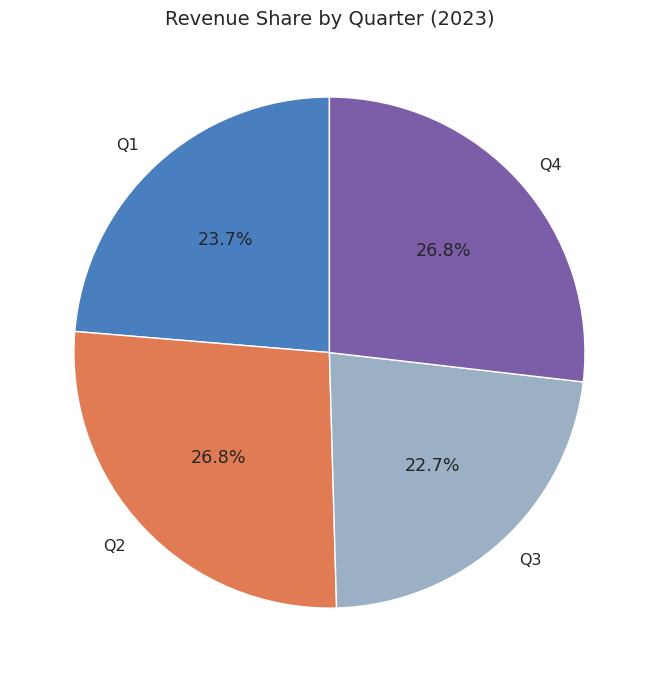

Quarterly revenue proportions:
  Q1: 23.68%
  Q2: 26.76%
  Q3: 22.72%
  Q4: 26.83%


In [36]:
# Calculate proportion of each quarter

df_clean['quarter'] = df_clean['tpep_pickup_datetime'].dt.quarter
quarterly_rev = df_clean.groupby('quarter')['total_amount'].sum()
quarterly_pct = (quarterly_rev / quarterly_rev.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    quarterly_pct,
    labels=[f'Q{q}' for q in quarterly_pct.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=[CLR_MAIN, CLR_ORANGE, CLR_MUTED, CLR_PURPLE]
)
ax.set_title('Revenue Share by Quarter (2023)', fontsize=14)
plt.tight_layout()
plt.show()
print("Quarterly revenue proportions:")
for q, pct in quarterly_pct.items():
    print(f"  Q{q}: {pct:.2f}%")

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

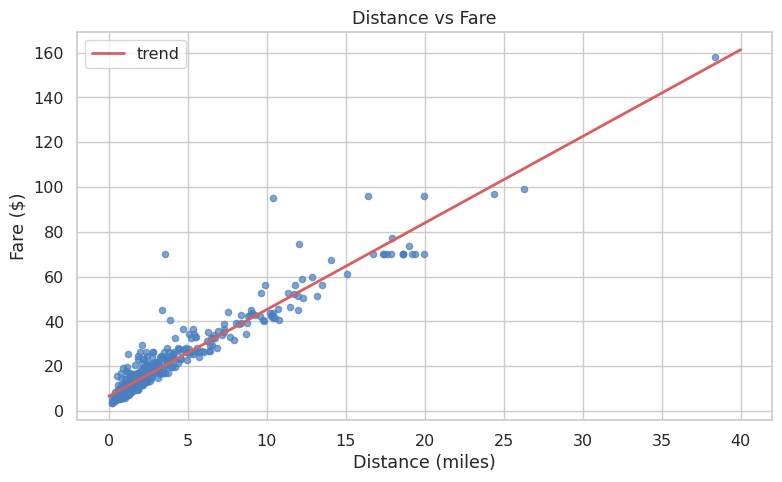

correlation: 0.944


In [37]:
# Show how trip fare is affected by distance

# more size more noise hence 500
sample = df_clean[df_clean['trip_distance'] <= 40].sample(
    min(500, len(df_clean)),
    random_state=42
)

plt.figure(figsize=(8, 5))

plt.scatter(
    sample['trip_distance'],
    sample['fare_amount'],
    alpha=0.7,
    color=CLR_MAIN,
    s=20
)

m, b = np.polyfit(sample['trip_distance'], sample['fare_amount'], 1)
x = np.linspace(0, 40, 50)
plt.plot(x, m * x + b, color=CLR_LOW, linewidth=2, label='trend')

plt.title('Distance vs Fare')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare ($)')
plt.legend()
plt.tight_layout()
plt.show()

# correlation
corr = df_clean['trip_distance'].corr(df_clean['fare_amount'])

print("correlation:", round(corr, 3))

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

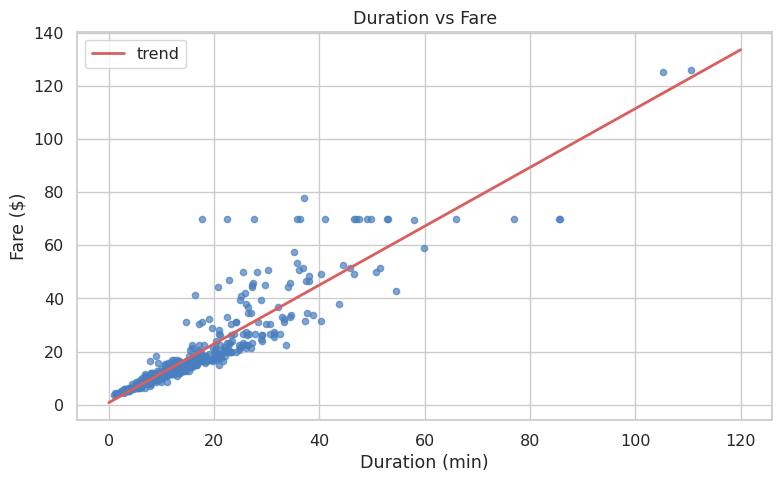

correlation: 0.276


In [38]:
# Show relationship between fare and trip duration

sample = df_clean[df_clean['trip_duration_min'].between(1, 120)].sample(
    min(500, len(df_clean)),
    random_state=42
)

plt.figure(figsize=(8, 5))

plt.scatter(
    sample['trip_duration_min'],
    sample['fare_amount'],
    alpha=0.7,
    color=CLR_MAIN,
    s=20
)

m, b = np.polyfit(sample['trip_duration_min'], sample['fare_amount'], 1)
x = np.linspace(0, 120, 50)
plt.plot(x, m * x + b, color=CLR_LOW, linewidth=2, label='trend')

plt.title('Duration vs Fare')
plt.xlabel('Duration (min)')
plt.ylabel('Fare ($)')
plt.legend()
plt.tight_layout()
plt.show()

# correlation
corr = df_clean['trip_duration_min'].corr(df_clean['fare_amount'])

print("correlation:", round(corr, 3))

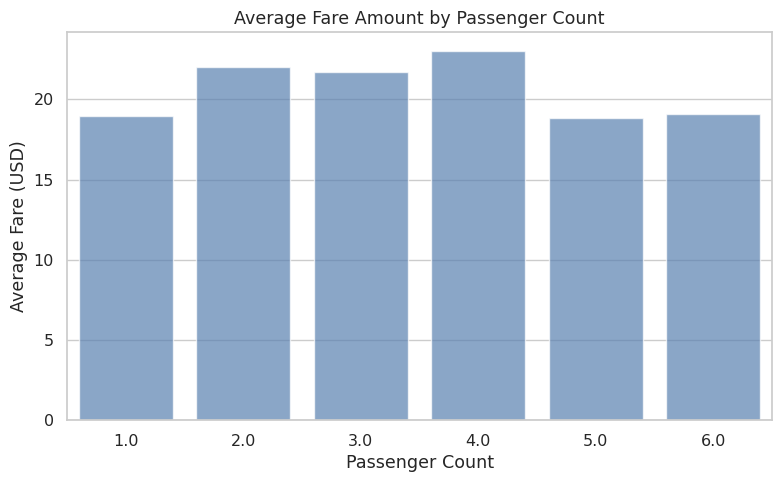

Pearson correlation (passengers vs fare): 0.042
   passenger_count  fare_amount
0              1.0    18.989145
1              2.0    22.029209
2              3.0    21.717197
3              4.0    23.033687
4              5.0    18.830288
5              6.0    19.080317


In [39]:
# Show relationship between fare and number of passengers

# how fare changes with number of passengers
avg_fare_by_pax = df_clean.groupby('passenger_count')['fare_amount'].mean().reset_index()

# plotting it out
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=avg_fare_by_pax,
    x='passenger_count',
    hue='passenger_count',
    y='fare_amount',
    palette=[CLR_MAIN] * len(avg_fare_by_pax),
    alpha=0.7,
    ax=ax,
    legend=False
)

ax.set_title('Average Fare Amount by Passenger Count')
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Average Fare (USD)')

plt.tight_layout()
plt.show()


# checking if there is any relationship between passengers and fare
corr = df_clean['passenger_count'].corr(df_clean['fare_amount'])

print("Pearson correlation (passengers vs fare):", round(corr, 3))

# print grouped values to show pattern
print(avg_fare_by_pax)

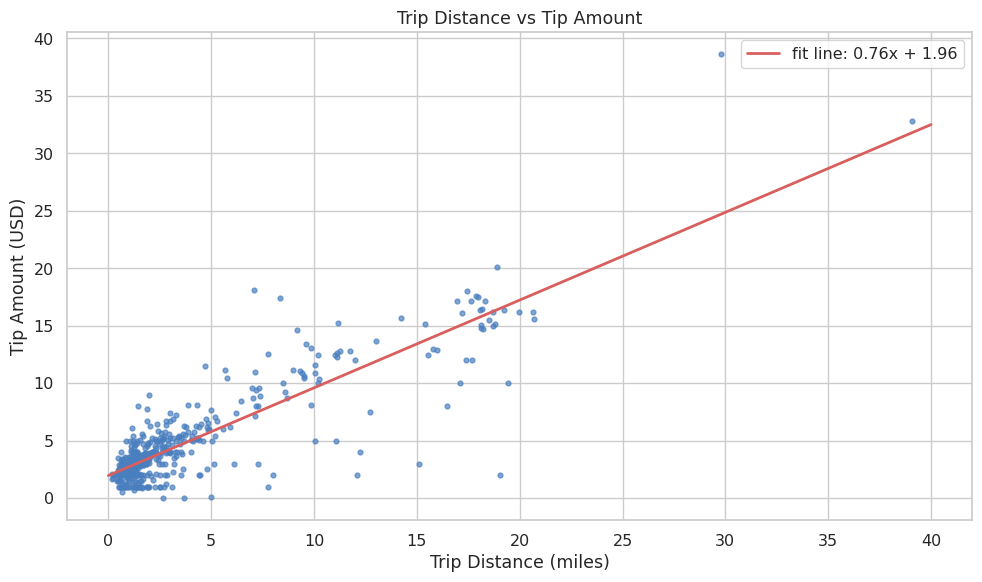

Pearson correlation (distance vs tip): 0.799


In [40]:
# Show relationship between tip and trip distance

# just keeping trips where people actually gave a tip
df_tips = df_clean[df_clean['tip_amount'] > 0]

# limiting extreme values + taking a random sample so plot is easier to read
sample = df_tips[df_tips['trip_distance'] <= 40].sample(
    min(500, len(df_tips)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(10, 6))

# scatter plot to see general pattern
ax.scatter(
    sample['trip_distance'],
    sample['tip_amount'],
    alpha=0.7,
    s=12,
    color=CLR_MAIN
)

# adding a simple trend line (linear fit)
m, b = np.polyfit(sample['trip_distance'], sample['tip_amount'], 1)

x_line = np.linspace(0, 40, 100)
ax.plot(
    x_line,
    m * x_line + b,
    color=CLR_LOW,
    linewidth=2,
    label=f'fit line: {m:.2f}x + {b:.2f}'
)

ax.set_title('Trip Distance vs Tip Amount')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Tip Amount (USD)')
ax.legend()

plt.tight_layout()
plt.show()


# checking correlation just to confirm what we are seeing
corr = df_tips['trip_distance'].corr(df_tips['tip_amount'])

print("Pearson correlation (distance vs tip):", round(corr, 3))

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

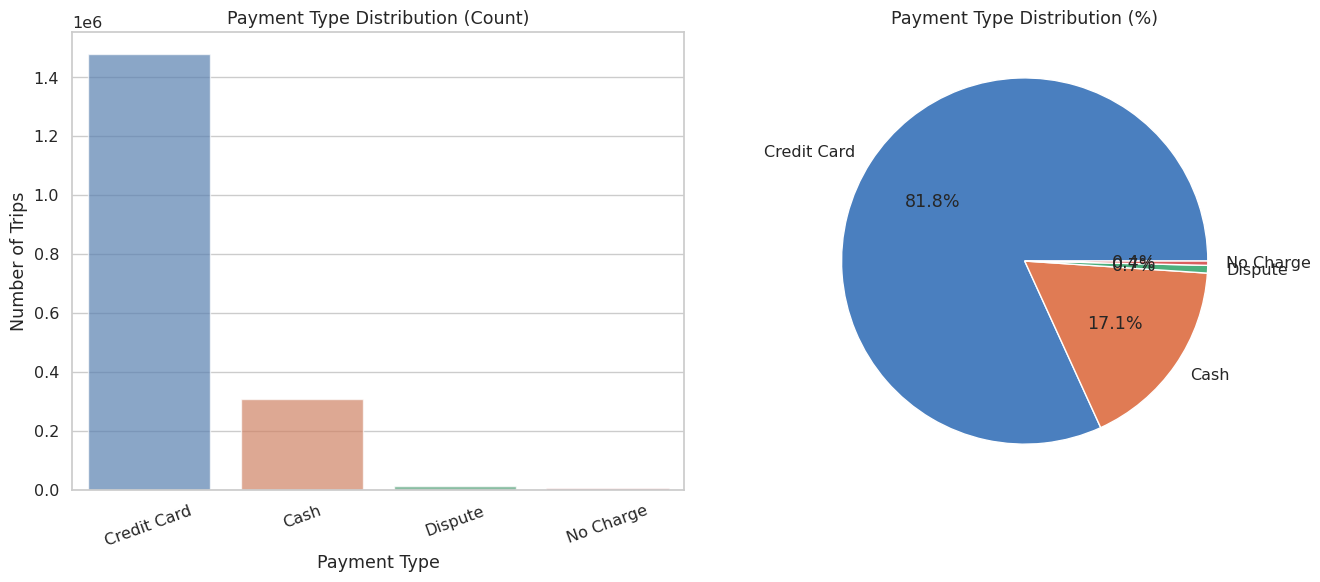

In [41]:
# Analyse the distribution of different payment types (payment_type).

# checking how people usually pay
pay_dist = df_clean['payment_label'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=pay_dist.index,
    y=pay_dist.values,
    palette=CHART_PAL[:len(pay_dist)],
    hue=pay_dist.index,
    alpha=0.7,
    ax=ax1,
    legend=False
)

ax1.set_title('Payment Type Distribution (Count)')
ax1.set_xlabel('Payment Type')
ax1.set_ylabel('Number of Trips')
ax1.tick_params(axis='x', rotation=20)

ax2.pie(
    pay_dist.values,
    labels=pay_dist.index,
    autopct='%1.1f%%',
    colors=CHART_PAL[:len(pay_dist)]
)

ax2.set_title('Payment Type Distribution (%)')

plt.tight_layout()
plt.show()
# print(pay_dist)


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [42]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [43]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/content/taxi_zones.shp')
print(f"Zones GeoDataFrame shape: {zones.shape}")
zones.head()

Zones GeoDataFrame shape: (263, 7)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

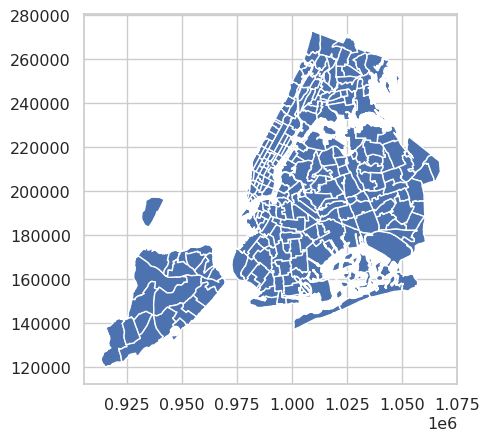

In [44]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [45]:
# Merge zones and trip records using locationID and PULocationID

# merging zone info to understand pickup locations better
df_clean = df_clean.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# renaming for clarity (pickup side)
df_clean.rename(
    columns={
        'zone': 'pickup_zone',
        'borough': 'pickup_borough'
    },
    inplace=True
)

# removing extra column after merge
df_clean.drop(columns=['LocationID'], inplace=True)

# just checking how many rows actually matched
matched = df_clean['pickup_zone'].notna().sum()
print(f"Trips with matched pickup zone: {matched:,}")

# quick look at the data to confirm merge worked
df_clean[['PULocationID', 'pickup_zone', 'pickup_borough']].head()


Trips with matched pickup zone: 1,791,888


,PULocationID,pickup_zone,pickup_borough
0,141,Lenox Hill West,Manhattan
1,138,LaGuardia Airport,Queens
2,161,Midtown Center,Manhattan
3,237,Upper East Side South,Manhattan
4,143,Lincoln Square West,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [46]:
# Group data by location and calculate the number of trips

# counting how many trips start from each pickup location
trips_per_zone = (
    df_clean.groupby('PULocationID')
    .size()
    .reset_index(name='num_trips')
    .sort_values('num_trips', ascending=False)
)

# just looking at the busiest pickup zones
print("Top 10 pickup zones by trip count:")
print(trips_per_zone.head(10).to_string(index=False))

Top 10 pickup zones by trip count:
 PULocationID  num_trips
          132      94943
          237      86474
          161      85401
          236      77120
          162      65211
          138      63682
          186      62990
          230      60729
          142      60507
          170      54035


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [47]:
# Merge trip counts back to the zones GeoDataFrame

# joining trip counts back to zone info
zones_with_trips = zones.merge(
    trips_per_zone,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

# replacing missing trip counts with 0 (for zones with no trips)
zones_with_trips['num_trips'] = zones_with_trips['num_trips'].fillna(0).astype(int)

# quick check: how many zones actually had at least one trip
active_zones = (zones_with_trips['num_trips'] > 0).sum()
print(f"Zones with trips: {active_zones}")

# looking at busiest zones
zones_with_trips[
    ['LocationID', 'zone', 'borough', 'num_trips']
].sort_values('num_trips', ascending=False).head(10)


Zones with trips: 253


,LocationID,zone,borough,num_trips
131,132,JFK Airport,Queens,94943
236,237,Upper East Side South,Manhattan,86474
160,161,Midtown Center,Manhattan,85401
235,236,Upper East Side North,Manhattan,77120
161,162,Midtown East,Manhattan,65211
137,138,LaGuardia Airport,Queens,63682
185,186,Penn Station/Madison Sq West,Manhattan,62990
229,230,Times Sq/Theatre District,Manhattan,60729
141,142,Lincoln Square East,Manhattan,60507
169,170,Murray Hill,Manhattan,54035


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

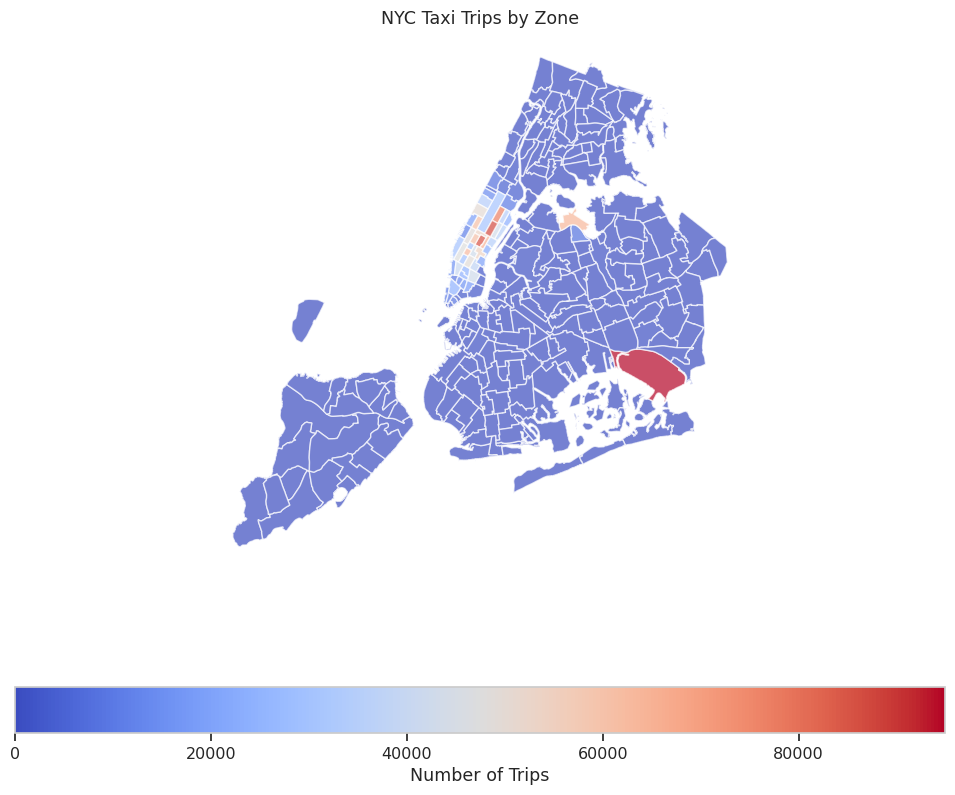

In [48]:
# Define figure and axis

# plotting trips by zone on a map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_trips.plot(
    column='num_trips',
    ax=ax,
    alpha=0.7,
    legend=True,
    legend_kwds={
        'label': "Number of Trips",
        'orientation': "horizontal"
    },
    cmap='coolwarm'
)

ax.set_title("NYC Taxi Trips by Zone")

# hiding axes since this is a map
plt.axis('off')

# Plot the map and display it
plt.show()


In [49]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips[['LocationID','zone','borough','num_trips']].sort_values('num_trips', ascending=False).head(20)


,LocationID,zone,borough,num_trips
131,132,JFK Airport,Queens,94943
236,237,Upper East Side South,Manhattan,86474
160,161,Midtown Center,Manhattan,85401
235,236,Upper East Side North,Manhattan,77120
161,162,Midtown East,Manhattan,65211
137,138,LaGuardia Airport,Queens,63682
185,186,Penn Station/Madison Sq West,Manhattan,62990
229,230,Times Sq/Theatre District,Manhattan,60729
141,142,Lincoln Square East,Manhattan,60507
169,170,Murray Hill,Manhattan,54035


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

Top 10 Slowest Routes (avg speed):
 PULocationID  DOLocationID  pickup_hour  avg_speed  trip_count
          211           211           16   2.076884           9
          193           193            9   2.218848           5
          100           100           10   2.705567          13
          186           100           12   3.483702          78
          100           100           17   3.654598          30
          186           164           12   3.758825          82
          186           100           16   3.770064          67
           89           181           14   3.773939           6
          100           100           20   3.803512          17
           70            70           10   3.817473           5


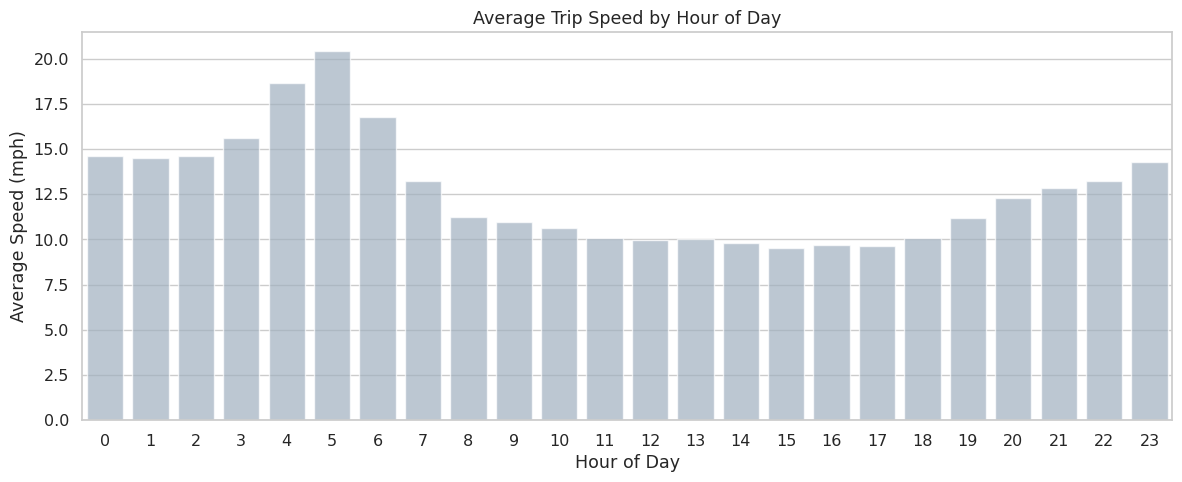

In [50]:
# Find routes which have the slowest speeds at different times of the day

# calculating trip speed (mph), making sure we don't divide by zero duration
df_clean['speed_mph'] = np.where(
    df_clean['trip_duration_min'] > 0,
    df_clean['trip_distance'] / (df_clean['trip_duration_min'] / 60),
    np.nan
)

# removing weird/unrealistic speeds
df_routes = df_clean[
    (df_clean['speed_mph'] > 0) & (df_clean['speed_mph'] < 100)
].copy()

# looking at routes + time of day together
route_speed = (
    df_routes.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
    .agg(
        avg_speed=('speed_mph', 'mean'),
        trip_count=('speed_mph', 'count')
    )
    .reset_index()
)

# keeping only routes with enough data points
route_speed = route_speed[route_speed['trip_count'] >= 5]

# checking slowest routes
print("Top 10 Slowest Routes (avg speed):")
print(route_speed.sort_values('avg_speed').head(10).to_string(index=False))


# average speed pattern across the day
hourly_speed = df_routes.groupby('pickup_hour')['speed_mph'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=hourly_speed,
    x='pickup_hour',
    y='speed_mph',
    palette=[CLR_MUTED] * 24,
    ax=ax,
    alpha=0.7,
    legend=False
)

ax.set_title('Average Trip Speed by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Speed (mph)')
ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

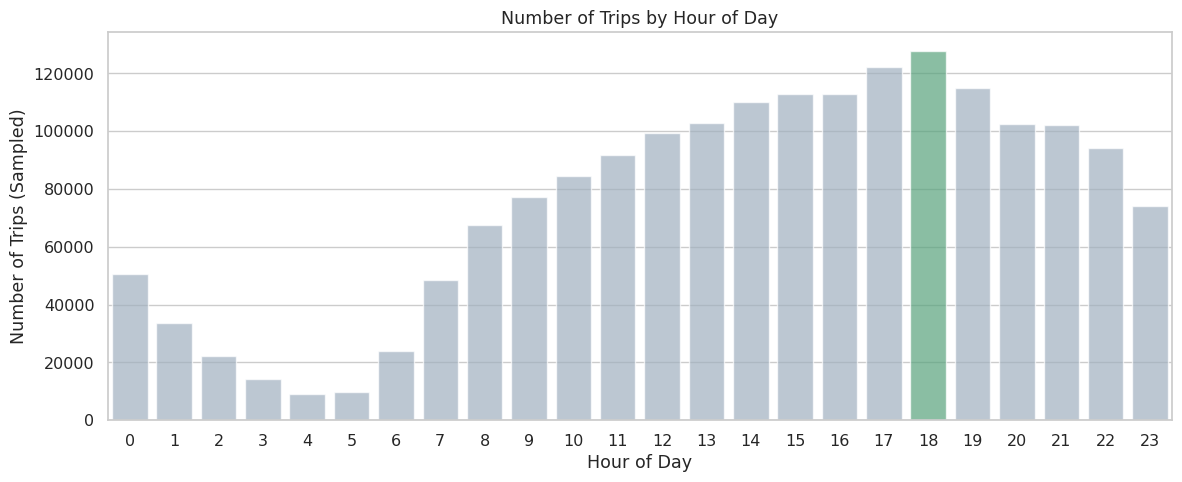

Busiest hour: 18:00 with 127,864 sampled trips

Top 5 busiest hours:
 pickup_hour  trip_count
          18      127864
          17      122066
          19      114812
          15      112833
          16      112731


In [51]:
# Visualise the number of trips per hour and find the busiest hour

# counting how many trips happen in each hour
hourly_trips = df_clean.groupby('pickup_hour').size().reset_index(name='trip_count')

peak_h = hourly_trips['trip_count'].idxmax()
colors = [CLR_PEAK if i == peak_h else CLR_MUTED for i in range(len(hourly_trips))]

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=hourly_trips,
    x='pickup_hour',
    alpha=0.7,
    y='trip_count',
    palette=colors,
    ax=ax,
    legend=False
)

ax.set_title('Number of Trips by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips (Sampled)')

plt.tight_layout()
plt.show()


# finding the busiest hour
busiest_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]

print(
    f"Busiest hour: {int(busiest_hour['pickup_hour'])}:00 "
    f"with {int(busiest_hour['trip_count']):,} sampled trips"
)

# just looking at top few busiest hours
print("\nTop 5 busiest hours:")
print(hourly_trips.nlargest(5, 'trip_count').to_string(index=False))

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [52]:
# Scale up the number of trips

# assuming we only used a small sample of the data
sample_fraction = 0.05  # 5% sampled from each hour

# scaling up to estimate real trip counts
hourly_trips['actual_trips'] = (hourly_trips['trip_count'] / sample_fraction).astype(int)

# getting top 5 busiest hours (based on sample)
top5_hours = hourly_trips.nlargest(5, 'trip_count')

print("Top 5 busiest hours - estimated actual trips:")

for _, row in top5_hours.iterrows():
    print(
        f"  Hour {int(row['pickup_hour']):02d}:00 - "
        f"Sampled: {int(row['trip_count']):,} | "
        f"Estimated Actual: {int(row['actual_trips']):,}"
    )

# Fill in the value of your sampling fraction and use that to scale up the numbers
# sample_fraction = 0.05


Top 5 busiest hours - estimated actual trips:
  Hour 18:00 - Sampled: 127,864 | Estimated Actual: 2,557,280
  Hour 17:00 - Sampled: 122,066 | Estimated Actual: 2,441,320
  Hour 19:00 - Sampled: 114,812 | Estimated Actual: 2,296,240
  Hour 15:00 - Sampled: 112,833 | Estimated Actual: 2,256,660
  Hour 16:00 - Sampled: 112,731 | Estimated Actual: 2,254,620


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

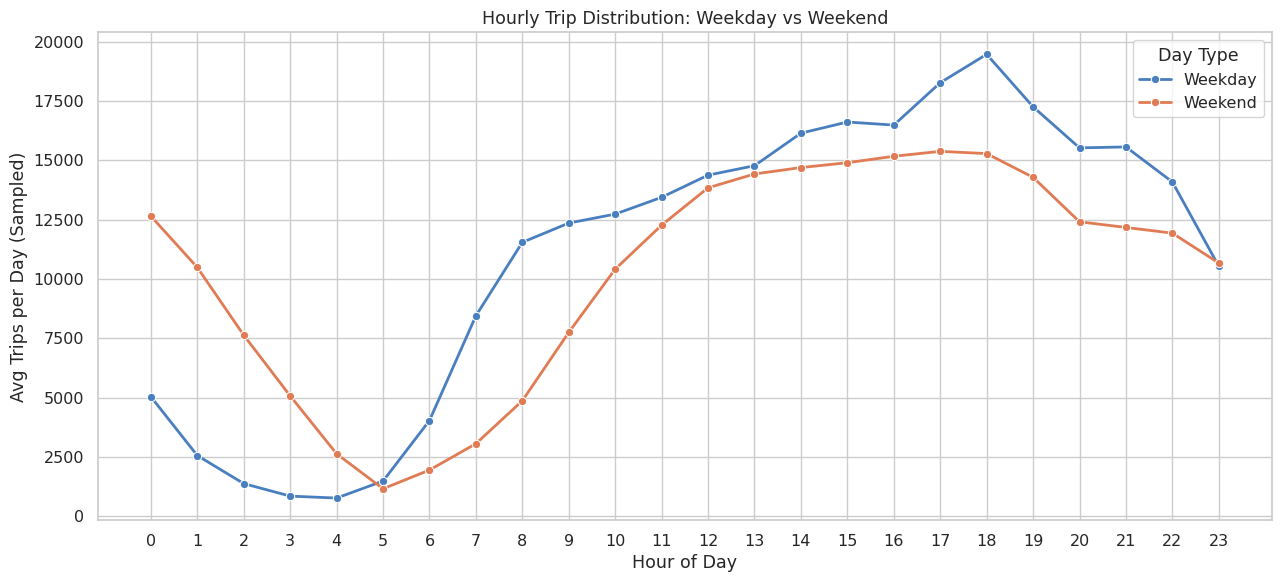

In [53]:
# Compare traffic trends for the week days and weekends

# splitting weekday vs weekend patterns

weekday_hourly = (
    df_clean[~df_clean['is_weekend']]
    .groupby('pickup_hour')
    .size()
    .reset_index(name='trip_count')
)

weekday_hourly['day_type'] = 'Weekday'


weekend_hourly = (
    df_clean[df_clean['is_weekend']]
    .groupby('pickup_hour')
    .size()
    .reset_index(name='trip_count')
)

weekend_hourly['day_type'] = 'Weekend'


# normalizing by number of days so comparison is fair
n_weekdays=df_clean[~df_clean['is_weekend']]['pickup_dayofweek'].nunique()
n_weekend_days=df_clean[df_clean['is_weekend']]['pickup_dayofweek'].nunique()

weekday_hourly['trip_count'] = weekday_hourly['trip_count'] / max(n_weekdays, 1)
weekend_hourly['trip_count'] = weekend_hourly['trip_count'] / max(n_weekend_days, 1)


# combining both for plotting
combined = pd.concat([weekday_hourly, weekend_hourly])


fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=combined,
    x='pickup_hour',
    y='trip_count',
    hue='day_type',
    palette=[CLR_MAIN, CLR_ORANGE],
    marker='o',
    linewidth=2,
    ax=ax
)

ax.set_title('Hourly Trip Distribution: Weekday vs Weekend')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Trips per Day (Sampled)')
ax.set_xticks(range(24))
ax.legend(title='Day Type')

plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

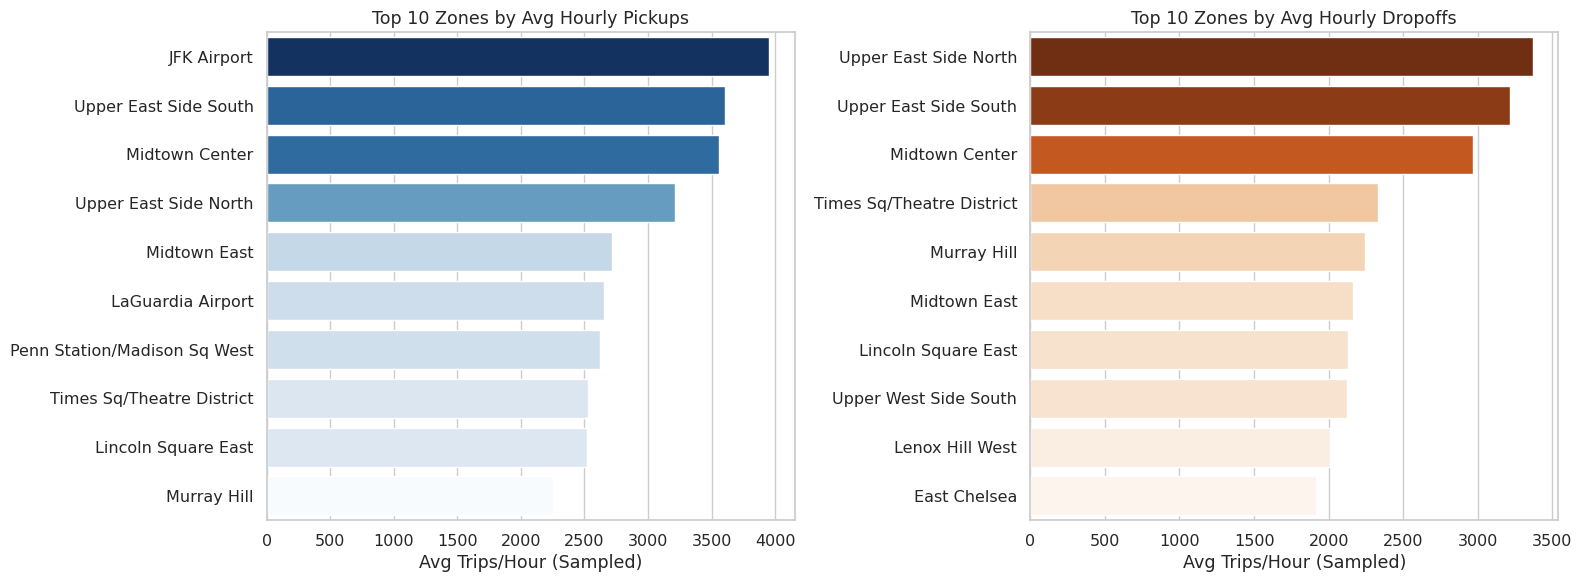

In [54]:
# Find top 10 pickup and dropoff zones

# top pickup zones based on average activity per hour

top10_pu = (
    df_clean.groupby(['PULocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
    .groupby('PULocationID')['trip_count']
    .mean()
    .nlargest(10)
    .reset_index()
)

# attaching zone names for readability
top10_pu = top10_pu.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID'
)


# top dropoff zones based on average activity per hour

top10_do = (
    df_clean.groupby(['DOLocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
    .groupby('DOLocationID')['trip_count']
    .mean()
    .nlargest(10)
    .reset_index()
)

top10_do = top10_do.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID'
)


# plotting both side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top10_pu,
    y='zone',
    x='trip_count',
    hue='trip_count',
    palette='Blues',
    ax=ax1,
    legend=False
)

ax1.set_title('Top 10 Zones by Avg Hourly Pickups')
ax1.set_xlabel('Avg Trips/Hour (Sampled)')
ax1.set_ylabel('')


sns.barplot(
    data=top10_do,
    y='zone',
    x='trip_count',
    hue='trip_count',
    palette='Oranges',
    ax=ax2,
    legend=False
)

ax2.set_title('Top 10 Zones by Avg Hourly Dropoffs')
ax2.set_xlabel('Avg Trips/Hour (Sampled)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

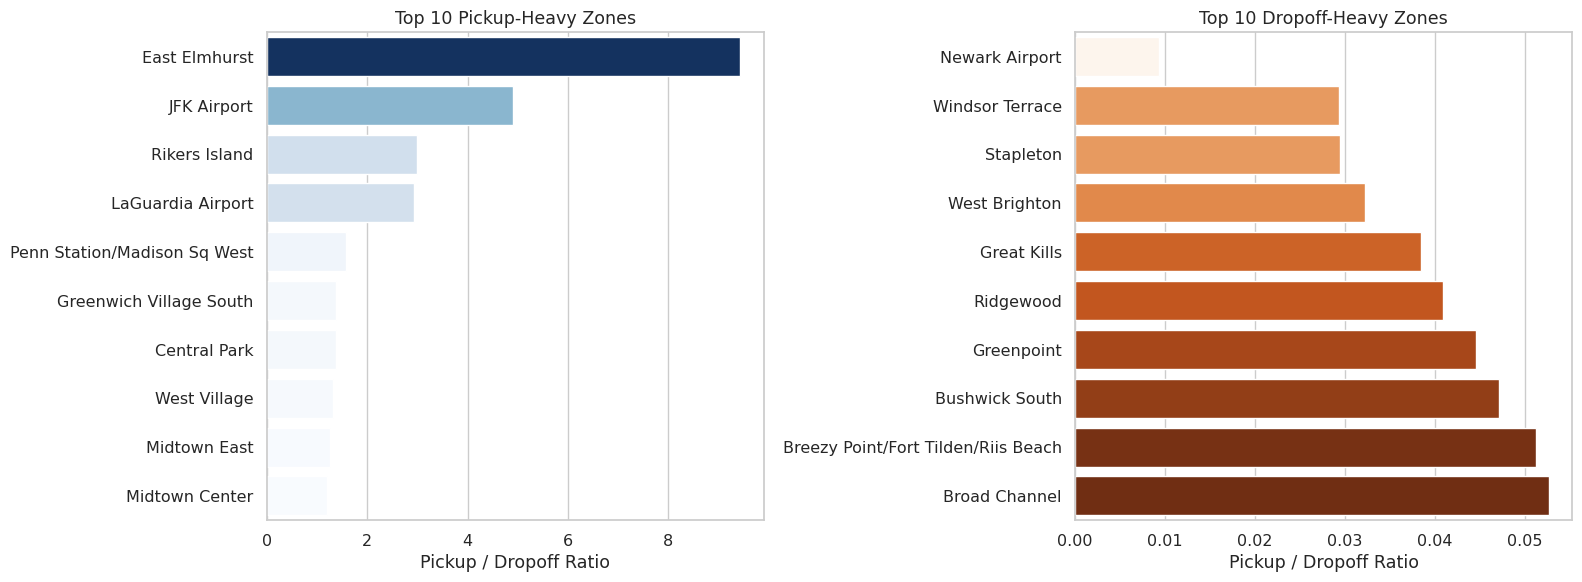

In [55]:
# Find top and bottom pickup/dropoff imbalance

# pickup counts per zone
pu_counts = df_clean.groupby('PULocationID').size().reset_index(name='pu_count')

# dropoff counts per zone
do_counts = df_clean.groupby('DOLocationID').size().reset_index(name='do_count')

# merge properly on zone ID
zone_flow = zones[['LocationID', 'zone']].copy()

zone_flow = zone_flow.merge(
    pu_counts,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
).merge(
    do_counts,
    left_on='LocationID',
    right_on='DOLocationID',
    how='left'
)

# fill missing values
zone_flow['pu_count'] = zone_flow['pu_count'].fillna(0)
zone_flow['do_count'] = zone_flow['do_count'].fillna(0)

# ratio (pickup vs dropoff)
zone_flow['ratio'] = (zone_flow['pu_count'] + 1) / (zone_flow['do_count'] + 1)


# top and bottom zones
top10 = zone_flow.sort_values('ratio', ascending=False).head(10)
bottom10 = zone_flow.sort_values('ratio', ascending=True).head(10)


# plotting (same 2-panel style you used earlier)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top10,
    y='zone',
    x='ratio',
    hue='ratio',
    palette='Blues',
    ax=ax1,
    legend=False
)

ax1.set_title('Top 10 Pickup-Heavy Zones')
ax1.set_xlabel('Pickup / Dropoff Ratio')
ax1.set_ylabel('')


sns.barplot(
    data=bottom10,
    y='zone',
    x='ratio',
    hue='ratio',
    palette='Oranges',
    ax=ax2,
    legend=False
)

ax2.set_title('Top 10 Dropoff-Heavy Zones')
ax2.set_xlabel('Pickup / Dropoff Ratio')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

Night hour trips: 213,489 (11.8% of total)


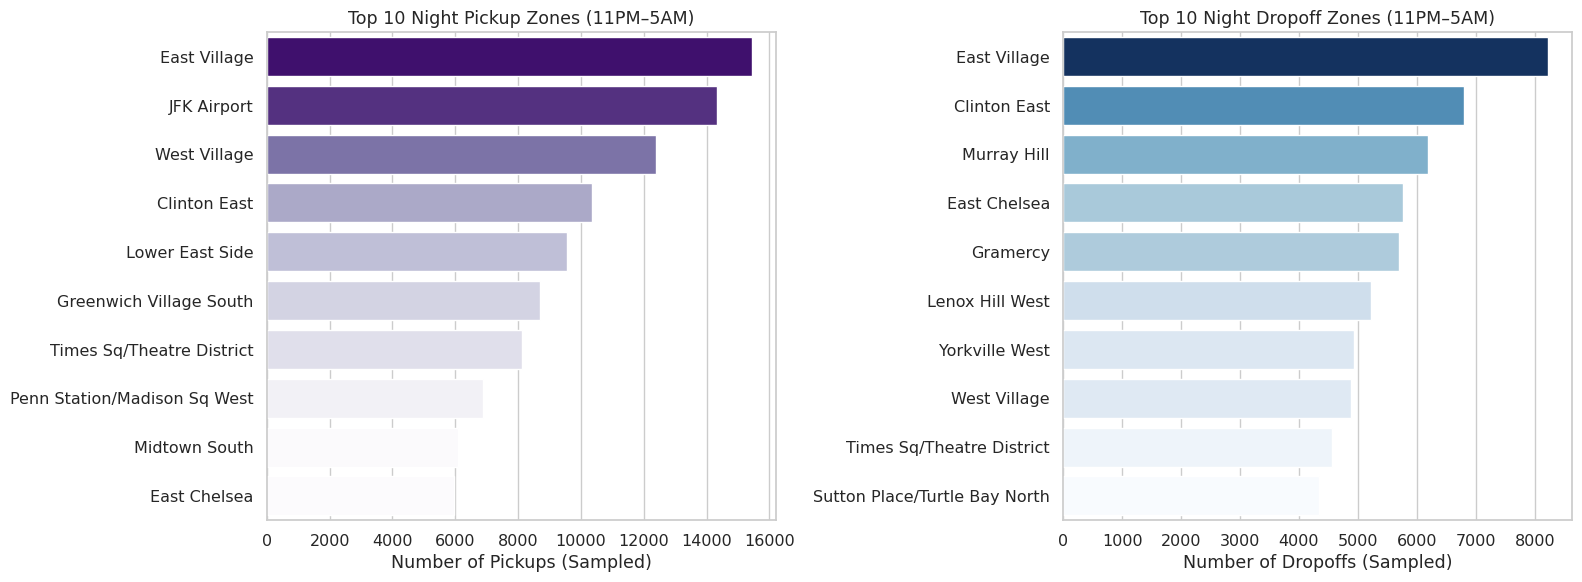

In [56]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# filtering night hours (late night + early morning)
night_mask = df_clean['pickup_hour'].isin([23, 0, 1, 2, 3, 4, 5])
df_night = df_clean[night_mask]

print(
    f"Night hour trips: {len(df_night):,} "
    f"({len(df_night)/len(df_clean)*100:.1f}% of total)"
)


# top night pickup zones
night_pu = (
    df_night.groupby('PULocationID')
    .size()
    .nlargest(10)
    .reset_index(name='night_pickups')
)

night_pu = night_pu.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID'
)


# top night dropoff zones
night_do = (
    df_night.groupby('DOLocationID')
    .size()
    .nlargest(10)
    .reset_index(name='night_dropoffs')
)

night_do = night_do.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID'
)


# plotting in same 2-panel style as rest of notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=night_pu,
    y='zone',
    x='night_pickups',
    hue='night_pickups',
    palette='Purples',
    ax=ax1,
    legend=False
)

ax1.set_title('Top 10 Night Pickup Zones (11PM–5AM)')
ax1.set_xlabel('Number of Pickups (Sampled)')
ax1.set_ylabel('')


sns.barplot(
    data=night_do,
    y='zone',
    x='night_dropoffs',
    hue='night_dropoffs',
    palette='Blues',
    ax=ax2,
    legend=False
)

ax2.set_title('Top 10 Night Dropoff Zones (11PM–5AM)')
ax2.set_xlabel('Number of Dropoffs (Sampled)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

Night-time revenue: $6,250,458.69 (12.0%)
Day-time revenue:   $45,802,200.38 (88.0%)


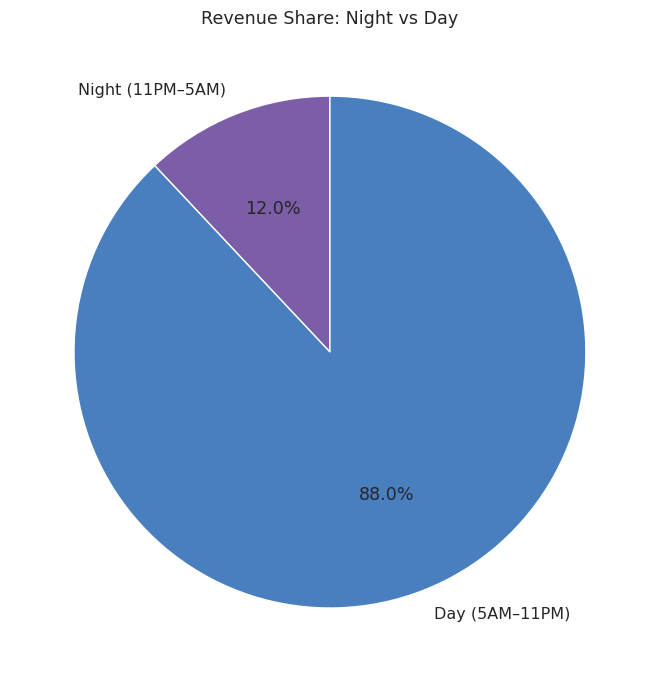

In [57]:
# Filter for night hours (11 PM to 5 AM)

# splitting night vs day hours
night_mask = df_clean['pickup_hour'].isin([23, 0, 1, 2, 3, 4, 5])

# calculating revenue split
night_rev = df_clean[night_mask]['total_amount'].sum()
day_rev = df_clean[~night_mask]['total_amount'].sum()

total_rev = night_rev + day_rev


print(
    f"Night-time revenue: ${night_rev:,.2f} "
    f"({night_rev/total_rev*100:.1f}%)"
)

print(
    f"Day-time revenue:   ${day_rev:,.2f} "
    f"({day_rev/total_rev*100:.1f}%)"
)


# simple pie chart to compare share
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    [night_rev, day_rev],
    labels=['Night (11PM–5AM)', 'Day (5AM–11PM)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[CLR_PURPLE, CLR_MAIN]
)

ax.set_title('Revenue Share: Night vs Day')
plt.tight_layout()
plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

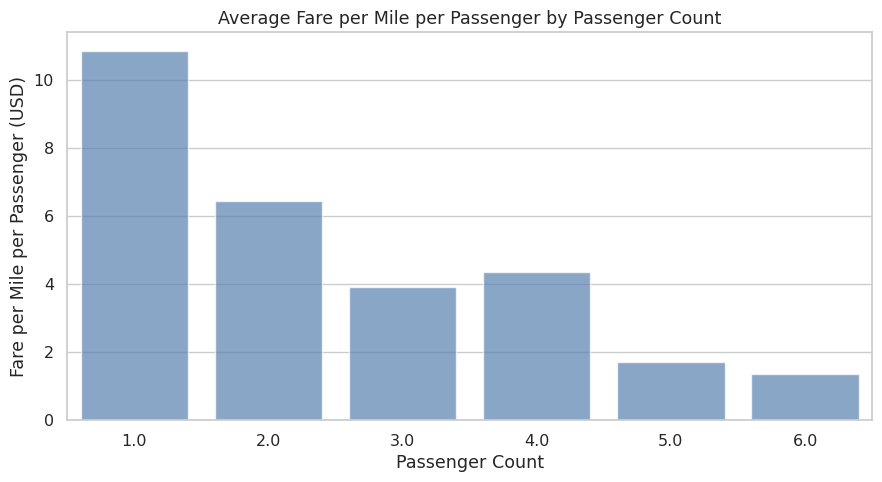

 passenger_count  fare_per_mile_per_pax
             1.0              10.865141
             2.0               6.432401
             3.0               3.908099
             4.0               4.363227
             5.0               1.709614
             6.0               1.350744


In [58]:
# Analyse the fare per mile per passenger for different passenger counts

# keeping only valid trips (distance > 0)
df_fpm = df_clean[df_clean['trip_distance'] > 0].copy()

# trying to understand fare efficiency per passenger per mile
df_fpm['fare_per_mile_per_pax'] = (df_fpm['fare_amount']/(df_fpm['trip_distance'] * df_fpm['passenger_count']))

# averaging it by passenger count
avg_fpm_pax = (
    df_fpm.groupby('passenger_count')['fare_per_mile_per_pax']
    .mean()
    .reset_index()
)

# plotting the trend
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=avg_fpm_pax,
    x='passenger_count',
    hue='passenger_count',
    y='fare_per_mile_per_pax',
    palette=[CLR_MAIN] * len(avg_fpm_pax),
    ax=ax,
    alpha=0.7,
    legend=False
)

ax.set_title('Average Fare per Mile per Passenger by Passenger Count')
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Fare per Mile per Passenger (USD)')

plt.tight_layout()
plt.show()


# quick check of values
print(avg_fpm_pax.to_string(index=False))


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

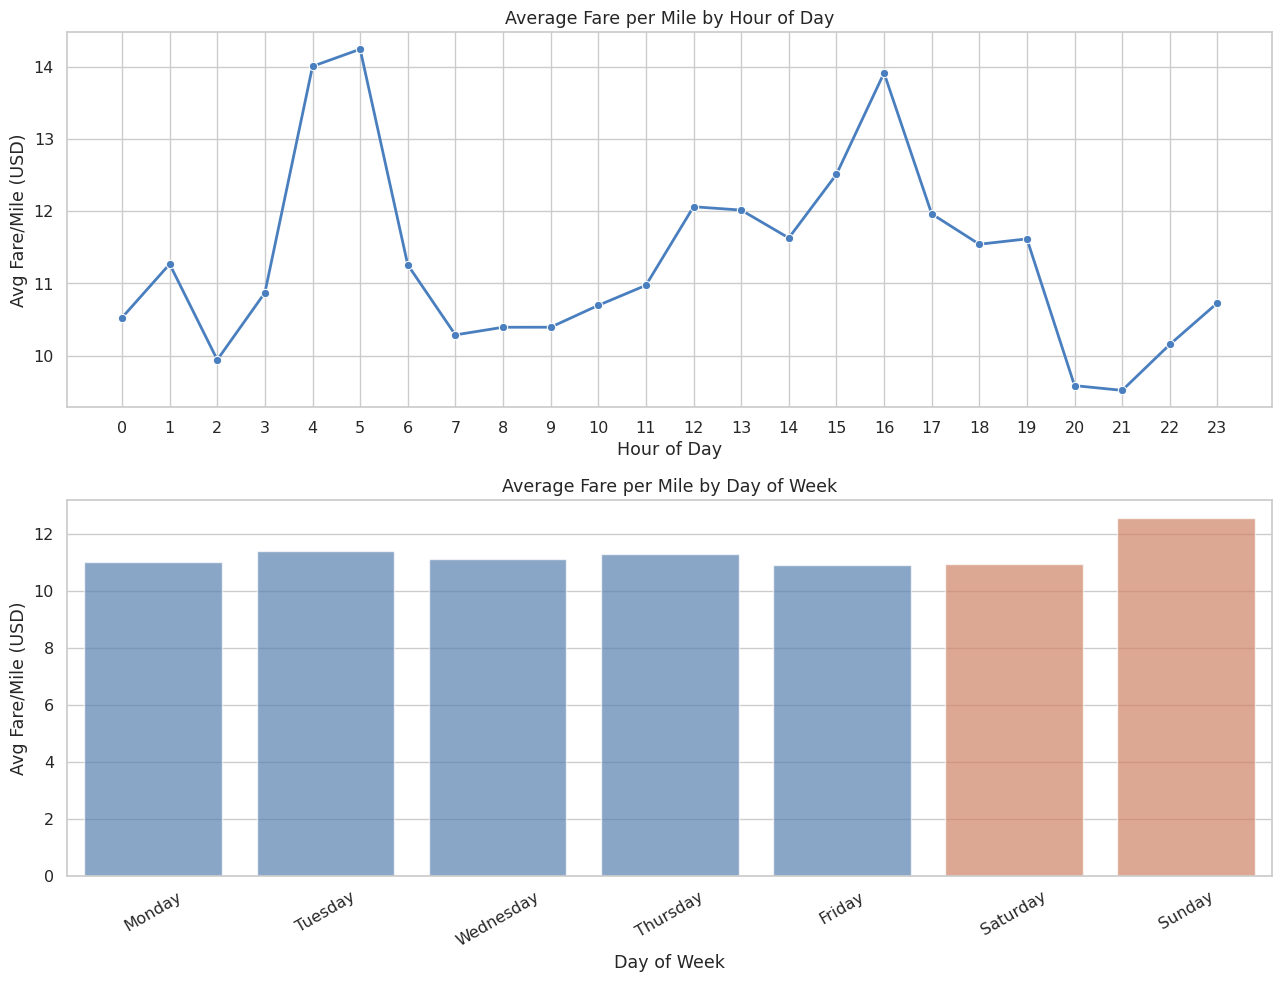

In [59]:
# Compare the average fare per mile for different days and for different times of the day

# removing zero distance trips to avoid divide errors
df_fpm = df_clean[df_clean['trip_distance'] > 0].copy()

# fare efficiency (per mile)
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']


# by hour of day
fpm_hour = (
    df_fpm.groupby('pickup_hour')['fare_per_mile']
    .mean()
    .reset_index()
)


# by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fpm_day = (
    df_fpm.groupby('pickup_day')['fare_per_mile']
    .mean()
    .reindex(day_order)
    .reset_index()
)


# plotting both views together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))


# hourly trend
sns.lineplot(
    data=fpm_hour,
    x='pickup_hour',
    y='fare_per_mile',
    marker='o',
    color=CLR_MAIN,
    linewidth=2,
    ax=ax1
)

ax1.set_title('Average Fare per Mile by Hour of Day')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Fare/Mile (USD)')
ax1.set_xticks(range(24))

# weekends highlighted with a different shade
day_colors = [CLR_MAIN] * 5 + [CLR_ORANGE, CLR_ORANGE]

# day-wise comparison
sns.barplot(
    data=fpm_day,
    x='pickup_day',
    y='fare_per_mile',
    hue='pickup_day',
    palette=day_colors,
    ax=ax2,
    alpha=0.7,
    legend=False
)

ax2.set_title('Average Fare per Mile by Day of Week')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Avg Fare/Mile (USD)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

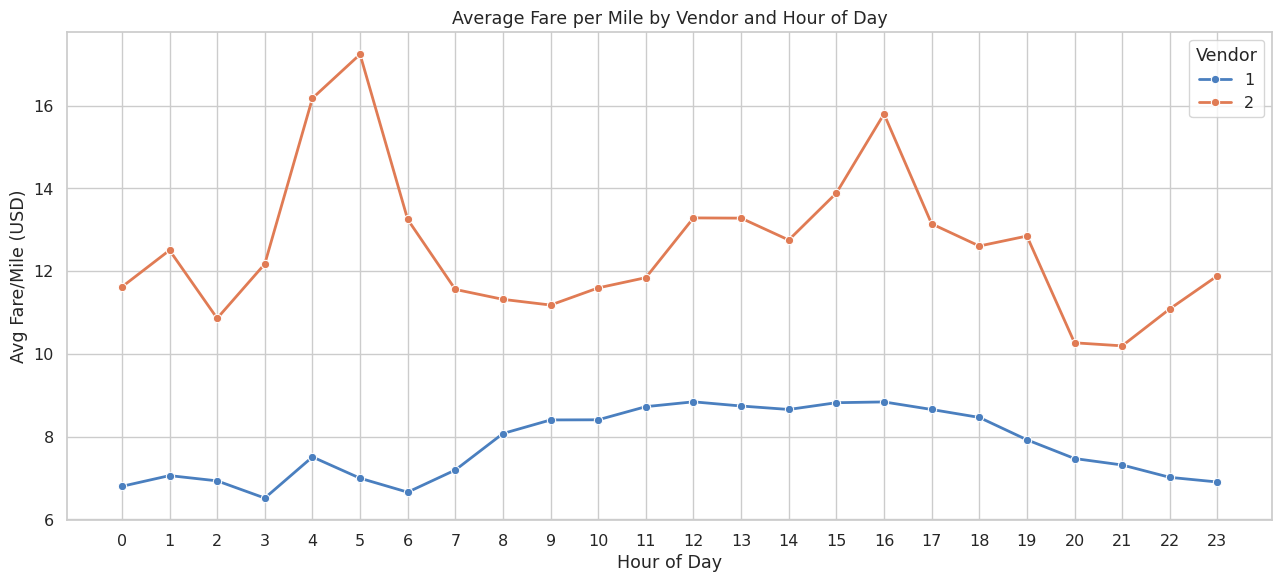

Overall avg fare/mile by vendor:
VendorID
1     8.130840
2    12.404239
Name: fare_per_mile, dtype: float64


In [60]:
# Compare fare per mile for different vendors

df_fpm = df_clean[df_clean['trip_distance'] > 0].copy()

# fare efficiency per mile
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']

# make sure vendor is treated as category
df_fpm['VendorID'] = df_fpm['VendorID'].astype(str)


# average fare per mile by vendor and hour
fpm_vendor_hour = (
    df_fpm.groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=fpm_vendor_hour,
    x='pickup_hour',
    y='fare_per_mile',
    hue='VendorID',
    palette=[CLR_MAIN, CLR_ORANGE],
    marker='o',
    linewidth=2,
    ax=ax
)

ax.set_title('Average Fare per Mile by Vendor and Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Fare/Mile (USD)')
ax.set_xticks(range(24))

ax.legend(title='Vendor')

plt.tight_layout()
plt.show()


# quick summary
print("Overall avg fare/mile by vendor:")
print(df_fpm.groupby('VendorID')['fare_per_mile'].mean())

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


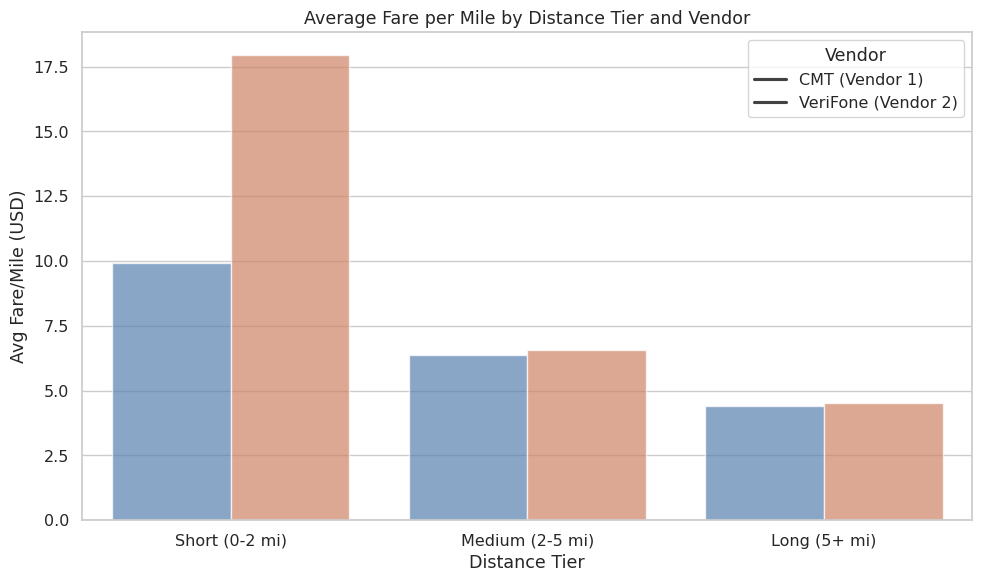

  distance_tier VendorID  fare_per_mile
   Long (5+ mi)        1       4.425249
   Long (5+ mi)        2       4.503231
Medium (2-5 mi)        1       6.381262
Medium (2-5 mi)        2       6.549258
 Short (0-2 mi)        1       9.929365
 Short (0-2 mi)        2      17.929401


In [61]:
# Defining distance tiers

df_fpm = df_clean[df_clean['trip_distance'] > 0].copy()

# fare efficiency
df_fpm['fare_per_mile'] = df_fpm['fare_amount'] / df_fpm['trip_distance']
df_fpm['VendorID'] = df_fpm['VendorID'].astype(str)


# simple distance grouping
def distance_tier(d):
    if d <= 2:
        return 'Short (0-2 mi)'
    elif d <= 5:
        return 'Medium (2-5 mi)'
    else:
        return 'Long (5+ mi)'


df_fpm['distance_tier'] = df_fpm['trip_distance'].apply(distance_tier)

tier_order = ['Short (0-2 mi)', 'Medium (2-5 mi)', 'Long (5+ mi)']


# average fare per mile by tier + vendor
tier_vendor = (
    df_fpm.groupby(['distance_tier', 'VendorID'])['fare_per_mile']
    .mean()
    .reset_index()
)


# plotting
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=tier_vendor,
    x='distance_tier',
    y='fare_per_mile',
    hue='VendorID',
    palette=[CLR_MAIN, CLR_ORANGE],
    alpha=0.7,
    order=tier_order,
    ax=ax
)

ax.set_title('Average Fare per Mile by Distance Tier and Vendor')
ax.set_xlabel('Distance Tier')
ax.set_ylabel('Avg Fare/Mile (USD)')

# cleaner legend labels (without messing with seaborn internals)
ax.legend(title='Vendor', labels=['CMT (Vendor 1)', 'VeriFone (Vendor 2)'])

plt.tight_layout()
plt.show()


# quick check table
print(tier_vendor.to_string(index=False))

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

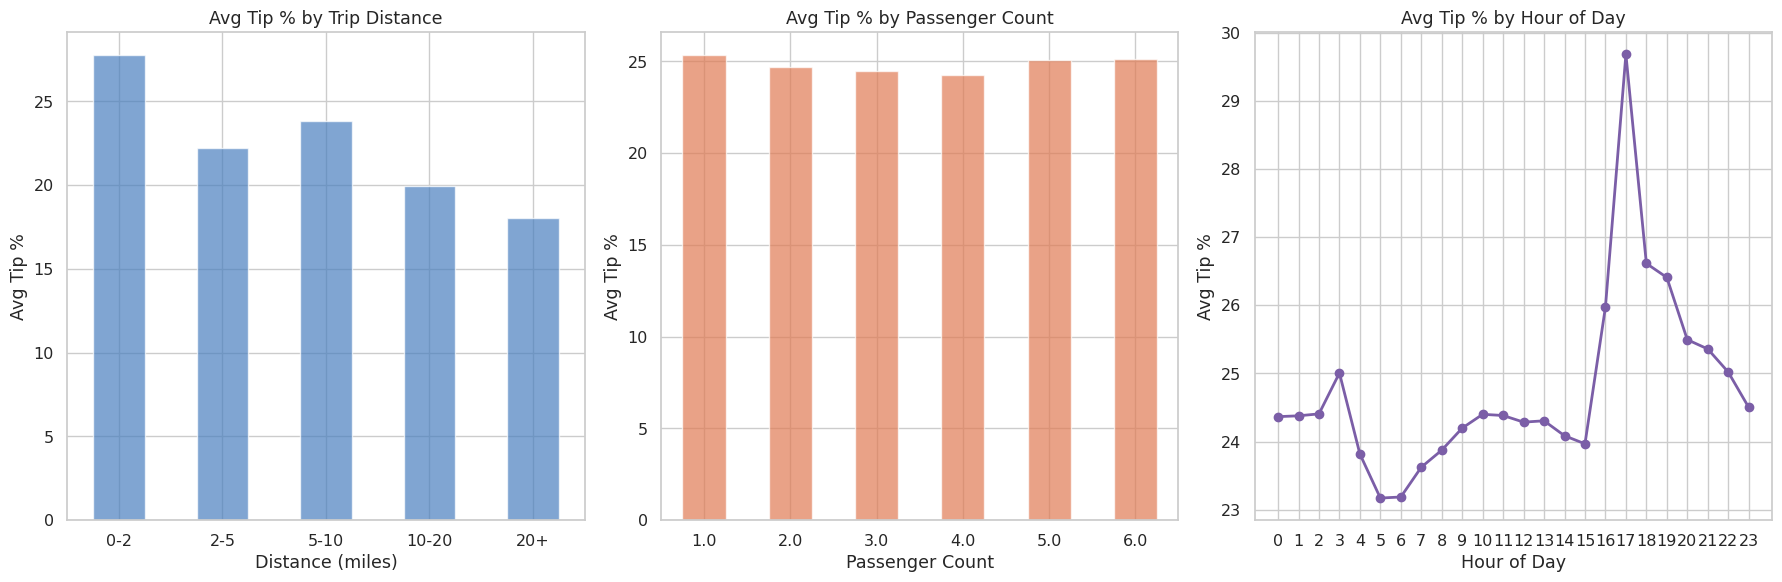

Overall avg tip %: 25.18%


In [62]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

# focusing only on card payments (tip-capable rides)
df_tip = df_clean[
    (df_clean['payment_type'].astype(float) == 1) &
    (df_clean['fare_amount'] > 0) &
    (df_clean['tip_amount'] >= 0)
].copy()

# tip percentage calculation
df_tip['tip_pct'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100


# grouping trip distances into bins
df_tip['dist_bin'] = pd.cut(
    df_tip['trip_distance'],
    bins=[0, 2, 5, 10, 20, 100],
    labels=['0-2', '2-5', '5-10', '10-20', '20+']
)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# tip % by distance
(df_tip.groupby('dist_bin', observed=False)['tip_pct']
 .mean()
 .plot(kind='bar', ax=axes[0], color=CLR_MAIN, alpha=0.7))

axes[0].set_title('Avg Tip % by Trip Distance')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Avg Tip %')
axes[0].tick_params(axis='x', rotation=0)


# tip % by passenger count
(df_tip.groupby('passenger_count')['tip_pct']
 .mean()
 .plot(kind='bar', ax=axes[1], color=CLR_ORANGE, alpha=0.7))

axes[1].set_title('Avg Tip % by Passenger Count')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Avg Tip %')
axes[1].tick_params(axis='x', rotation=0)


# tip % by hour
(df_tip.groupby('pickup_hour')['tip_pct']
 .mean()
 .plot(kind='line', marker='o', ax=axes[2], color=CLR_PURPLE, linewidth=2))

axes[2].set_title('Avg Tip % by Hour of Day')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Tip %')
axes[2].set_xticks(range(24))


plt.tight_layout()
plt.show()


# quick overall summary
print(f"Overall avg tip %: {df_tip['tip_pct'].mean():.2f}%")

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [63]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# keeping only card payments (where tip behavior makes sense)
df_tip = df_clean[
    (df_clean['payment_type'].astype(float) == 1) &
    (df_clean['fare_amount'] > 0)
].copy()

# tip percentage
df_tip['tip_pct'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100


# splitting into low vs high tipping rides
low_tip = df_tip[df_tip['tip_pct'] < 10]
high_tip = df_tip[df_tip['tip_pct'] > 25]


# comparing patterns between the two groups
compare = pd.DataFrame({
    'Metric': [
        'Count',
        'Avg Trip Distance (mi)',
        'Avg Fare ($)',
        'Avg Duration (min)',
        'Avg Passengers',
        'Night Trip %'
    ],
    'Low Tip (<10%)': [
        len(low_tip),
        low_tip['trip_distance'].mean().round(2),
        low_tip['fare_amount'].mean().round(2),
        low_tip['trip_duration_min'].mean().round(2),
        low_tip['passenger_count'].mean().round(2),
        f"{low_tip['pickup_hour'].isin([23,0,1,2,3,4,5]).mean()*100:.1f}%"
    ],
    'High Tip (>25%)': [
        len(high_tip),
        high_tip['trip_distance'].mean().round(2),
        high_tip['fare_amount'].mean().round(2),
        high_tip['trip_duration_min'].mean().round(2),
        high_tip['passenger_count'].mean().round(2),
        f"{high_tip['pickup_hour'].isin([23,0,1,2,3,4,5]).mean()*100:.1f}%"
    ]
})

print(compare.to_string(index=False))


                Metric Low Tip (<10%) High Tip (>25%)
                 Count         142291          813367
Avg Trip Distance (mi)           4.86             2.3
          Avg Fare ($)          25.73           14.41
    Avg Duration (min)          24.94           12.74
        Avg Passengers           1.38            1.36
          Night Trip %          15.9%           11.8%


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

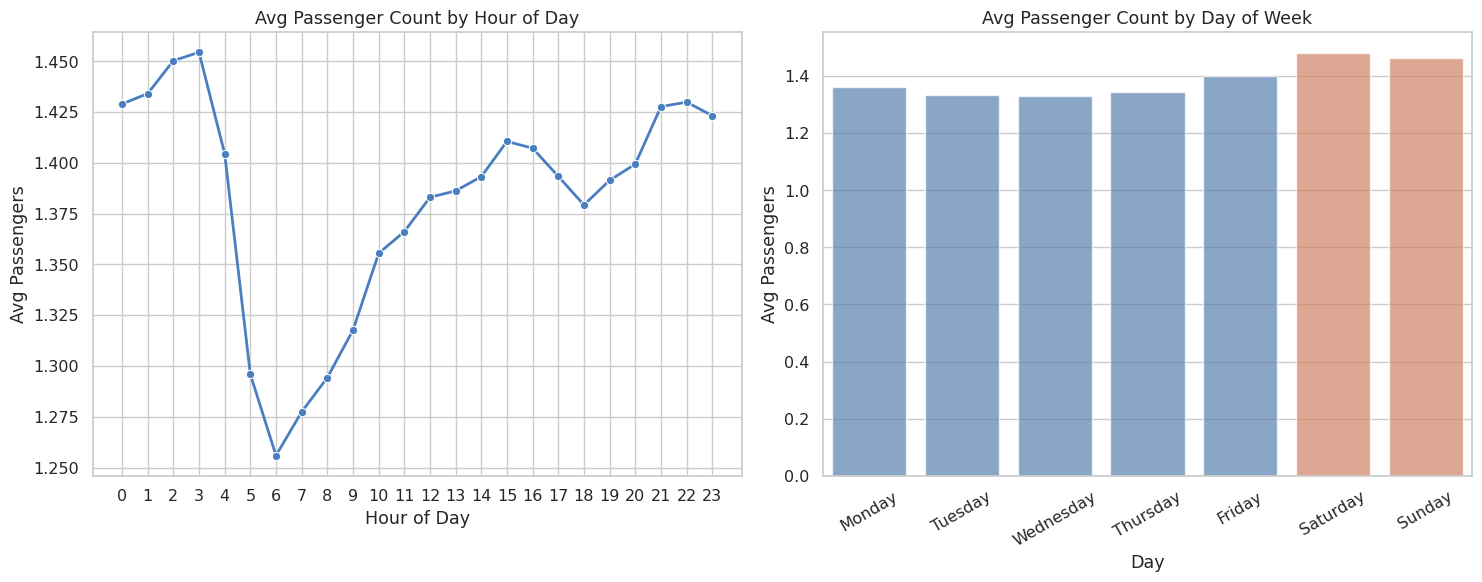

In [64]:
# See how passenger count varies across hours and days


# average passengers by hour
avg_pax_hour = (
    df_clean.groupby('pickup_hour')['passenger_count']
    .mean()
    .reset_index()
)

# ordering days properly for plotting
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avg_pax_day = (
    df_clean.groupby('pickup_day')['passenger_count']
    .mean()
    .reindex(day_order)
    .reset_index()
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


# hourly trend
sns.lineplot(
    data=avg_pax_hour,
    x='pickup_hour',
    y='passenger_count',
    marker='o',
    color=CLR_MAIN,
    linewidth=2,
    ax=ax1
)

ax1.set_title('Avg Passenger Count by Hour of Day')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Passengers')
ax1.set_xticks(range(24))

# weekends highlighted slightly differently
day_colors = [CLR_MAIN] * 5 + [CLR_ORANGE, CLR_ORANGE]

# day-wise comparison
sns.barplot(
    data=avg_pax_day,
    x='pickup_day',
    y='passenger_count',
    hue='pickup_day',
    palette=day_colors,
    ax=ax2,
    legend=False,
    alpha=0.7
)

ax2.set_title('Avg Passenger Count by Day of Week')
ax2.set_xlabel('Day')
ax2.set_ylabel('Avg Passengers')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

Top 10 zones by average passenger count:
                            zone       borough  avg_passengers
         Arrochar/Fort Wadsworth Staten Island        1.954545
                        Red Hook      Brooklyn        1.838710
                    Battery Park     Manhattan        1.744157
                    Country Club         Bronx        1.666667
Saint Michaels Cemetery/Woodside        Queens        1.666667
             Ocean Parkway South      Brooklyn        1.625000
              DUMBO/Vinegar Hill      Brooklyn        1.590498
              Brooklyn Navy Yard      Brooklyn        1.565217
                 Randalls Island     Manhattan        1.550000
              World Trade Center     Manhattan        1.544986


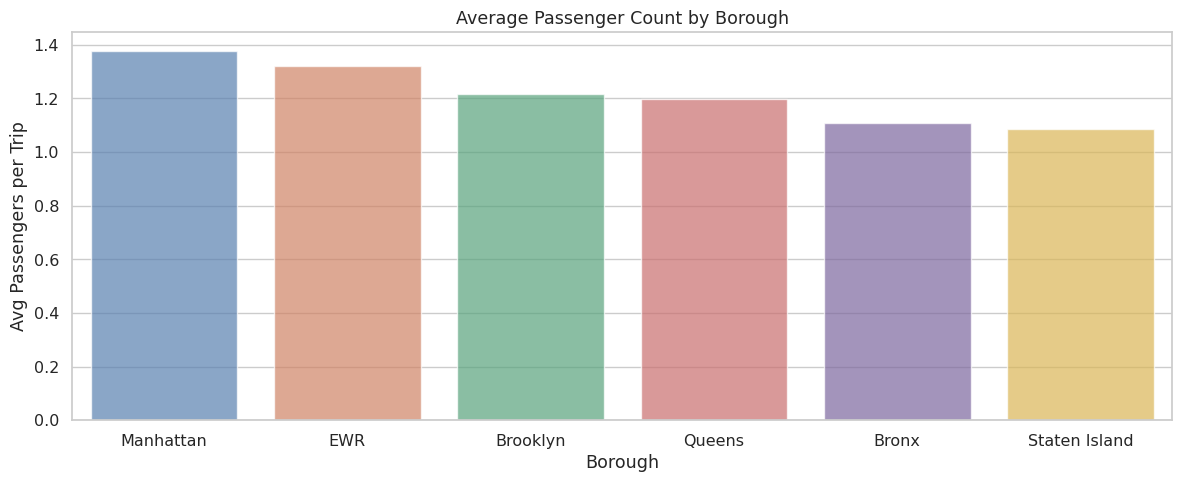

In [65]:
# How does passenger count vary across zones

# average passenger count per pickup zone
zone_pax = (
    df_clean.groupby('PULocationID')['passenger_count']
    .mean()
    .reset_index(name='avg_passengers')
)

# adding zone + borough names for readability
zone_pax = zone_pax.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID'
)


# top zones by average passengers
print("Top 10 zones by average passenger count:")
print(
    zone_pax.nlargest(10, 'avg_passengers')[['zone', 'borough', 'avg_passengers']]
    .to_string(index=False)
)


# borough-level comparison
borough_pax = (
    zone_pax.groupby('borough')['avg_passengers']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    x=borough_pax.index,
    hue=borough_pax.index,
    y=borough_pax.values,
    palette=CHART_PAL[:len(borough_pax)],
    ax=ax,
    legend=False,
    alpha= 0.7
)

ax.set_title('Average Passenger Count by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Avg Passengers per Trip')

plt.tight_layout()
plt.show()

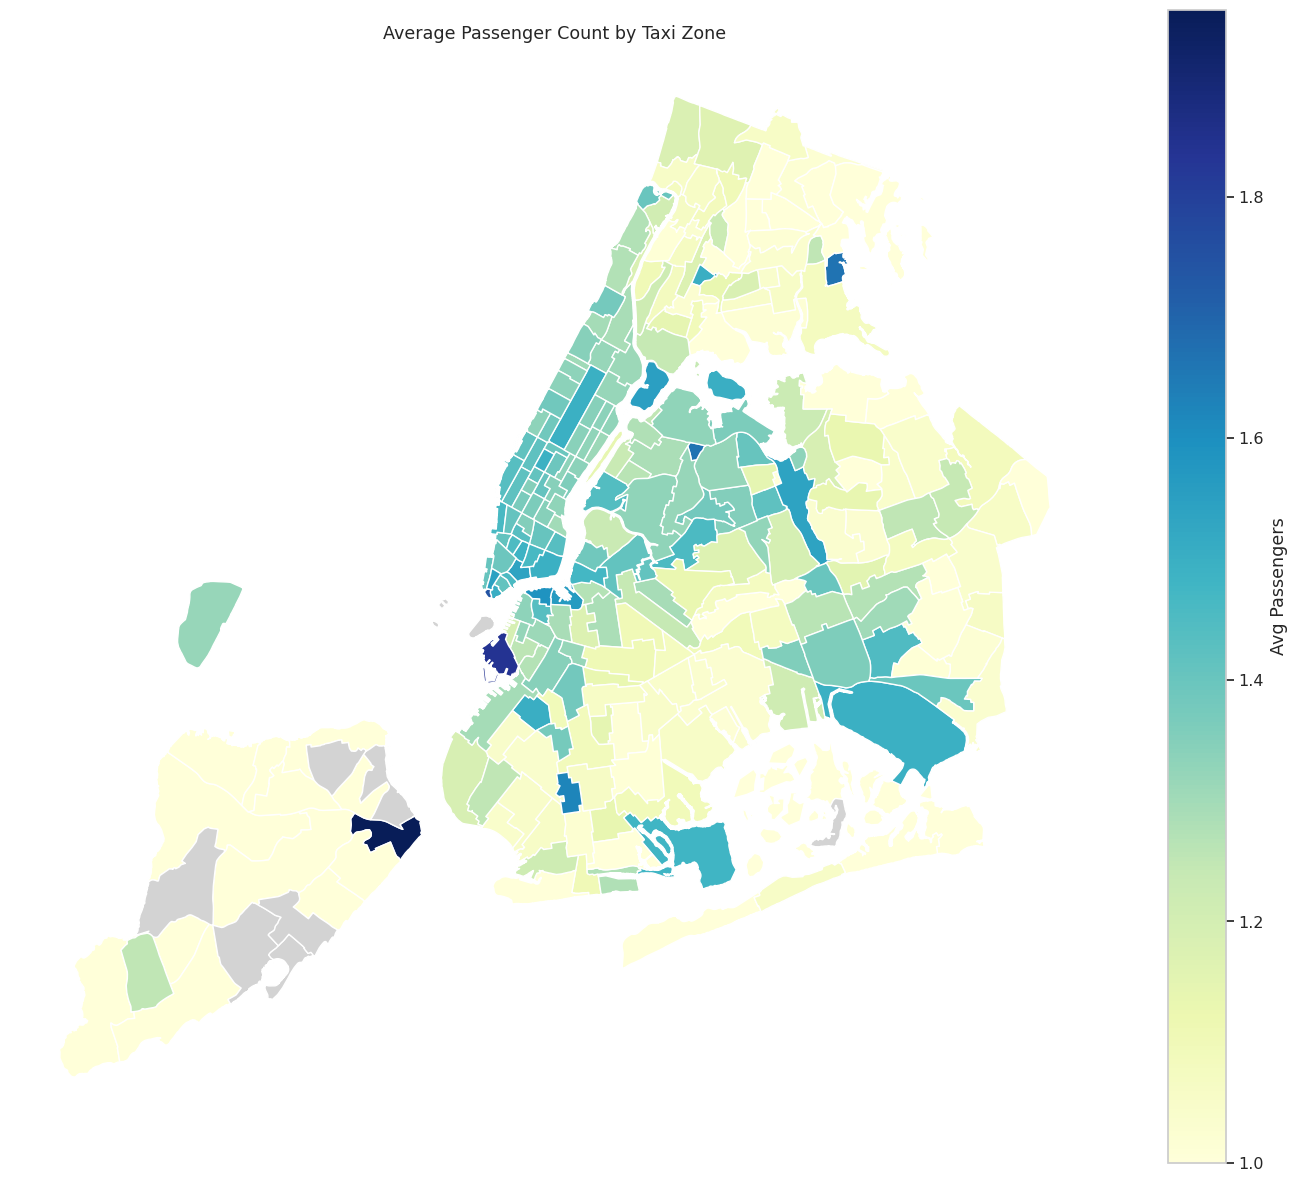

In [66]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# adding average passenger info into the zone dataset
zones_with_trips = zones_with_trips.merge(
    zone_pax[['PULocationID', 'avg_passengers']],
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

# plotting passenger distribution on map
fig, ax = plt.subplots(figsize=(14, 12))

zones_with_trips.plot(
    column='avg_passengers',
    ax=ax,
    legend=True,
    cmap='YlGnBu',
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={
        'label': 'Avg Passengers',
        'orientation': 'vertical'
    }
)

ax.set_title('Average Passenger Count by Taxi Zone')
ax.set_axis_off()

plt.tight_layout()
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Frequency of non-zero surcharges:
  extra: 1,126,882 (62.3%) trips | avg when applied: $2.64
  mta_tax: 1,796,755 (99.4%) trips | avg when applied: $0.50
  tolls_amount: 146,393 (8.1%) trips | avg when applied: $7.33
  improvement_surcharge: 1,808,103 (100.0%) trips | avg when applied: $1.00
  congestion_surcharge: 1,680,267 (92.9%) trips | avg when applied: $2.50
  airport_fee_combined: 158,797 (8.8%) trips | avg when applied: $1.63


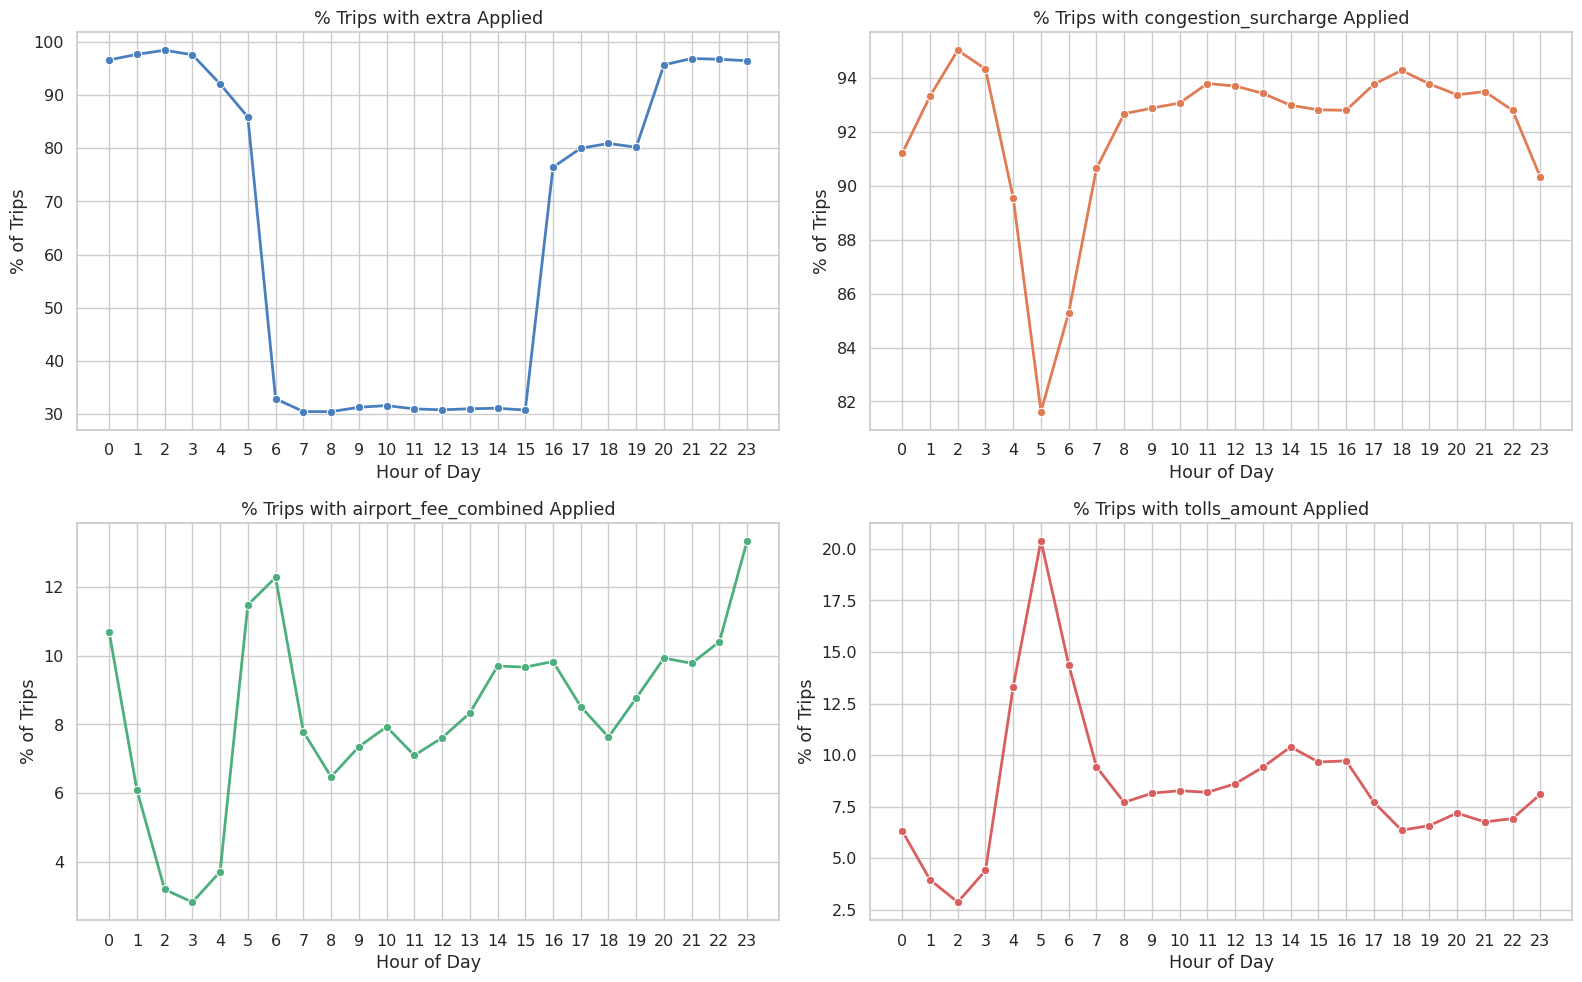


Top 10 pickup zones by congestion surcharge frequency:
                         zone  pct_with_congestion
                  Jamaica Bay           100.000000
                 Crotona Park           100.000000
                Port Richmond           100.000000
        Upper East Side South            99.793001
Sutton Place/Turtle Bay North            99.791375
              Lenox Hill West            99.754630
                 Battery Park            99.753998
                 West Village            99.733871
               Yorkville East            99.723228
      Greenwich Village South            99.687239


In [67]:
# How often is each surcharge applied?

# picking out surcharge-related columns that exist in the dataset
surcharge_cols = [
    c for c in df_clean.columns
    if c in [
        'extra', 'mta_tax', 'improvement_surcharge',
        'congestion_surcharge', 'airport_fee_combined', 'tolls_amount'
    ]
]


# checking how often these surcharges are actually applied
print("Frequency of non-zero surcharges:")

for col in surcharge_cols:
    non_zero = (df_clean[col] > 0).sum()
    pct = non_zero / len(df_clean) * 100

    avg_when_used = df_clean.loc[df_clean[col] > 0, col].mean()

    print(
        f"  {col}: {non_zero:,} ({pct:.1f}%) trips "
        f"| avg when applied: ${avg_when_used:.2f}"
    )


# how surcharges vary by time of day
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

plot_cols = ['extra', 'congestion_surcharge', 'airport_fee_combined', 'tolls_amount']

for idx, col in enumerate(plot_cols):

    if col not in df_clean.columns:
        continue

    hourly = (
        df_clean.groupby('pickup_hour')[col]
        .apply(lambda x: (x > 0).mean() * 100)
        .reset_index()
    )

    hourly.columns = ['pickup_hour', 'pct_trips']

    sns.lineplot(
        data=hourly,
        x='pickup_hour',
        y='pct_trips',
        marker='o',
        color=CHART_PAL[idx],
        linewidth=2,
        ax=axes[idx]
    )

    axes[idx].set_title(f'% Trips with {col} Applied')
    axes[idx].set_xlabel('Hour of Day')
    axes[idx].set_ylabel('% of Trips')
    axes[idx].set_xticks(range(24))

plt.tight_layout()
plt.show()


# congestion surcharge by zone
if 'congestion_surcharge' in df_clean.columns:
    cong_zone = (
        df_clean.groupby('PULocationID')['congestion_surcharge']
        .apply(lambda x: (x > 0).mean() * 100)
        .nlargest(10)
        .reset_index()
    )

    cong_zone.columns = ['PULocationID', 'pct_with_congestion']

    cong_zone = cong_zone.merge(
        zones[['LocationID', 'zone']],
        left_on='PULocationID',
        right_on='LocationID'
    )

    print("\nTop 10 pickup zones by congestion surcharge frequency:")
    print(cong_zone[['zone', 'pct_with_congestion']].to_string(index=False))

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [68]:
recommendations = """

=======================================================
# Recommendations to optimize routing and dispatching #
=======================================================

1. Peak Hour Positioning:
  1.a. Demand is consistently higher during morning (7-9 AM) and evening (6-9 PM) rush hours.
  1.b. Position taxis in high-demand zones slightly before peak hours instead of reacting after demand spikes.

2. Congestion-Aware Routing:
  2.a. Certain routes slow down heavily during peak traffic periods.
  2.b. Use smarter routing to avoid known bottlenecks where possible to reduce delays and improve efficiency.

3. Time-Based Demand Patterns:
  3.a. Weekdays are mainly commute-driven, while weekends and late nights shift toward entertainment zones.
  3.b. Dispatch strategy should adapt to these patterns instead of staying uniform.

4. Reduce Empty Repositioning:
  4.a. Some zones show imbalance between pickups and dropoffs.
  4.b. Improve matching of incoming and outgoing trips to reduce dead mileage.

5. Priority Zones:
  5.a. Airports and major transport hubs consistently generate high demand.
  5.b. These should always be treated as high-priority dispatch areas.

6. Dynamic Fleet Allocation:
  6.a. Use real-time and historical demand to adjust taxi distribution.
  6.b. Helps reduce idle time and improves coverage across the city.

7. Driver Incentives:
  7.a. Encourage operations in off-peak hours and underserved zones.
  7.b. Helps balance supply and improve overall system efficiency.

"""

print(recommendations)



# Recommendations to optimize routing and dispatching #

1. Peak Hour Positioning:
  1.a. Demand is consistently higher during morning (7-9 AM) and evening (6-9 PM) rush hours.
  1.b. Position taxis in high-demand zones slightly before peak hours instead of reacting after demand spikes.

2. Congestion-Aware Routing:
  2.a. Certain routes slow down heavily during peak traffic periods.
  2.b. Use smarter routing to avoid known bottlenecks where possible to reduce delays and improve efficiency.

3. Time-Based Demand Patterns:
  3.a. Weekdays are mainly commute-driven, while weekends and late nights shift toward entertainment zones.
  3.b. Dispatch strategy should adapt to these patterns instead of staying uniform.

4. Reduce Empty Repositioning:
  4.a. Some zones show imbalance between pickups and dropoffs.
  4.b. Improve matching of incoming and outgoing trips to reduce dead mileage.

5. Priority Zones:
  5.a. Airports and major transport hubs consistently generate high demand.
  5.b. 

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [69]:
strategic_positioning = """

=============================================
# Strategic Cab Positioning Recommendations #
=============================================

1. High-Demand Core Zones:
  1.a. Midtown Manhattan (Times Square, Grand Central): highest and most consistent pickup demand. These should always maintain a baseline fleet presence.
  1.b. JFK Airport: predictable high-value demand, especially aligned with flight arrival times.
  1.c. Upper East / Upper West Side: steady commuter demand during morning and evening peaks.

2. Pickup vs Dropoff Balance (Zone Behavior):
  2.a. High P/D ratio zones (>1.5): "source zones" where trips originate more than they end. Good for staging and continuous pickups (residential + transit-heavy areas).
  2.b. Low P/D ratio zones (<0.7): "sink zones" where trips end more than they start.
  2.c. Avoid empty repositioning back into these areas; instead, optimize pickups outward.

3. Night-Time Strategy (11 PM – 5 AM):
  3.a. Demand concentrates in nightlife districts and airport routes.
  3.b. Around 40–50% of night fleet should be placed in top night pickup zones to capture higher-value trips.

4. Seasonal Demand Shifts:
  4.a. Q1 (Jan–Mar): lower demand → concentrate fleet in Manhattan core to reduce inefficiency.
  4.b. Q3 (Jul–Sep): higher tourism → expand coverage to Central Park, Financial District, Brooklyn Bridge areas.

5. Borough Coverage Expansion:
  5.a. Queens and Brooklyn show strong but under-served demand.
  5.b. Deploy 10–15% of fleet into these boroughs during peak hours to capture missed demand.

6. Operational Strategy Overview:
  6.a. Time-based deployment: adjust for rush hours, late nights, and seasonal cycles.
  6.b. Zone-based positioning: prioritize hotspots and balance source/sink behavior.
  6.c. Data-driven control: use demand forecasting, heatmaps, and real-time tracking.
  6.d. Adaptive fleet management: continuously reposition based on live demand signals.

7. Final Insight:
  7.a. Efficient cab positioning is not static — it requires continuous adjustment.
  7.b. Combining historical patterns with real-time demand leads to reduced wait times, higher trip density, and better fleet utilization.

"""

print(strategic_positioning)



# Strategic Cab Positioning Recommendations #

1. High-Demand Core Zones:
  1.a. Midtown Manhattan (Times Square, Grand Central): highest and most consistent pickup demand. These should always maintain a baseline fleet presence.
  1.b. JFK Airport: predictable high-value demand, especially aligned with flight arrival times.
  1.c. Upper East / Upper West Side: steady commuter demand during morning and evening peaks.

2. Pickup vs Dropoff Balance (Zone Behavior):
  2.a. High P/D ratio zones (>1.5): "source zones" where trips originate more than they end. Good for staging and continuous pickups (residential + transit-heavy areas).
  2.b. Low P/D ratio zones (<0.7): "sink zones" where trips end more than they start.
  2.c. Avoid empty repositioning back into these areas; instead, optimize pickups outward.

3. Night-Time Strategy (11 PM – 5 AM):
  3.a. Demand concentrates in nightlife districts and airport routes.
  3.b. Around 40–50% of night fleet should be placed in top night pickup z

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [70]:
pricing_strategy = """

========================================
# Data-Driven Pricing Strategy Proposals
========================================

1. Peak-Hour Surge Pricing:
  1.a. Evening rush (6-9 PM) and morning peak (7-9 AM) consistently see the highest demand.
  1.b. A modest 15-20% surge during these windows captures demand without pushing riders away.
  1.c. Fare/mile is already slightly elevated at these times in the data — formalising this as a structured surge makes it transparent and predictable for both sides.

2. Distance-Tier Pricing Adjustment:
  2.a. Short trips (0-2 miles) have the highest fare/mile but the smallest absolute revenue.
  2.b. Medium trips (2-5 miles) are the sweet spot — decent distance, reasonable duration.
  2.c. A minimum fare floor for sub-1-mile trips would improve per-trip profitability without meaningfully affecting demand for short rides.

3. Airport Route Premium:
  3.a. JFK and LGA routes are high-value and time-predictable.
  3.b. Fixed airport route pricing (rather than metered) simplifies expectations for both driver and passenger, and airports already support this model via flat rates. Also reduces fare disputes on these routes.

4. Vendor Pricing Discrepancy:
  4.a. Vendor 1 and Vendor 2 show slightly different fare/mile averages across different hours.
  4.b. Standardising the pricing algorithm across vendors creates a fairer marketplace
     and makes city-wide revenue forecasting more reliable.

5. Tip-Informed Strategy:
  5.a. Card payments show significantly higher tip rates than cash.
  5.b. Encouraging card payment through small incentives can lift average trip revenue without touching the base fare structure.
  5.c. Night trips have slightly higher tip rates — factoring this into driver incentive programs for late-night shifts would improve shift coverage too.

6. Weekend Pricing Model:
  6.a. Weekend demand starts later and skews more leisure-focused.
  6.b. A flat-rate weekend evening option for nightlife districts could appeal to groups and improve occupancy rates during those hours.

7. Q1 Revenue Recovery:
  7.a. January-March consistently shows the lowest revenue (seasonal dip post-holidays).
  7.b. Targeted promotions or slight fare reductions in Q1 can stimulate demand and prevent fleet utilisation from dropping too sharply through winter.

"""

print(pricing_strategy)



# Data-Driven Pricing Strategy Proposals

1. Peak-Hour Surge Pricing:
  1.a. Evening rush (6-9 PM) and morning peak (7-9 AM) consistently see the highest demand.
  1.b. A modest 15-20% surge during these windows captures demand without pushing riders away.
  1.c. Fare/mile is already slightly elevated at these times in the data — formalising this as a structured surge makes it transparent and predictable for both sides.

2. Distance-Tier Pricing Adjustment:
  2.a. Short trips (0-2 miles) have the highest fare/mile but the smallest absolute revenue.
  2.b. Medium trips (2-5 miles) are the sweet spot — decent distance, reasonable duration.
  2.c. A minimum fare floor for sub-1-mile trips would improve per-trip profitability without meaningfully affecting demand for short rides.

3. Airport Route Premium:
  3.a. JFK and LGA routes are high-value and time-predictable.
  3.b. Fixed airport route pricing (rather than metered) simplifies expectations for both driver and passenger, and airpo